# Intelligent Customer Segmentation and Marketing Campaign Optimization System
**Course:** Data Science (BE05016021) â€“ PBL Activity, L.D. College of Engineering
**Author:** Manasvi
**Dataset:** Customer Personality Analysis (Kaggle) â€“ 2,240 customers, 29 attributes

**Objectives**
1. Clean and prepare customer data (feature engineering)
2. Descriptive analytics (EDA) to understand customer behaviour
3. Sampling & Estimation â€“ confidence intervals and hypothesis tests
4. Linear Regression â€“ predict customer total spending
5. Customer Segmentation â€“ K-Means clustering
6. Classification â€“ Logistic Regression, Decision Tree, Random Forest to predict campaign response
7. Interactive Streamlit dashboard for business stakeholders

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.append(os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")

## Step 1: Data Understanding and Cleaning
### 1.1 Load the raw data
The Kaggle file is **tab separated**, so we use `sep='\t'`.

In [2]:
raw = utils.load_raw()
print("Shape:", raw.shape)
raw.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

### 1.2 Data quality checks
We check for missing values, constant columns, duplicate rows and invalid values.

In [4]:
print("Missing values:\n", raw.isna().sum()[raw.isna().sum() > 0], "\n")
print("Duplicate rows:", raw.drop(columns="ID").duplicated().sum(), "\n")
print("Constant columns:", [c for c in raw.columns if raw[c].nunique() == 1], "\n")
print("Education values:", raw["Education"].value_counts().to_dict(), "\n")
print("Marital_Status values:", raw["Marital_Status"].value_counts().to_dict(), "\n")
print("Oldest birth year:", raw["Year_Birth"].min(), "| Max income:", raw["Income"].max())

Missing values:
 Income    24
dtype: int64 

Duplicate rows: 182 

Constant columns: ['Z_CostContact', 'Z_Revenue'] 

Education values: {'Graduation': 1127, 'PhD': 486, 'Master': 370, '2n Cycle': 203, 'Basic': 54} 

Marital_Status values: {'Married': 864, 'Together': 580, 'Single': 480, 'Divorced': 232, 'Widow': 77, 'Alone': 3, 'Absurd': 2, 'YOLO': 2} 

Oldest birth year: 1893 | Max income: 666666.0


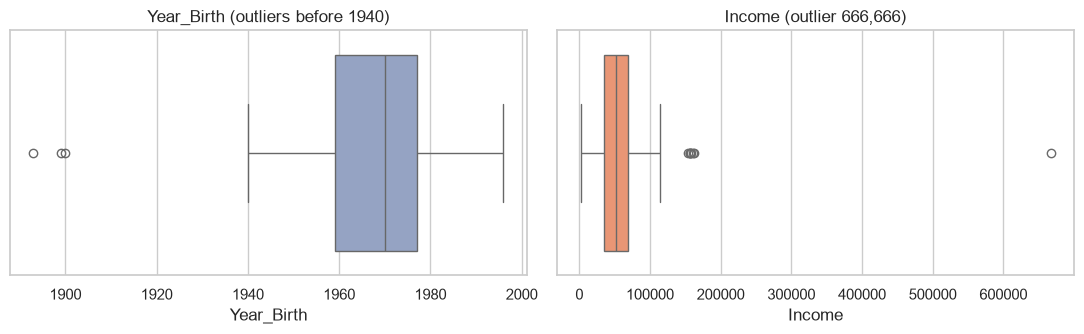

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=raw["Year_Birth"], ax=ax[0], color="#8da0cb"); ax[0].set_title("Year_Birth (outliers before 1940)")
sns.boxplot(x=raw["Income"], ax=ax[1], color="#fc8d62"); ax[1].set_title("Income (outlier 666,666)")
save("01_outliers_before_cleaning"); plt.show()

**Findings**
- **182 duplicate rows** (identical in all 28 columns except ID – the same customer registered twice) → remove.
- `Income` has **24 missing values** â†’ fill with the **median** (robust to outliers).
- `Z_CostContact` and `Z_Revenue` are **constant** (zero variance) â†’ drop. `ID` is just an identifier â†’ drop.
- `Year_Birth` has impossible values (1893, 1899, 1900 â†’ age 115+) â†’ remove rows with Year_Birth < 1940.
- `Income` has one extreme value (666,666) â†’ remove rows with Income > 600,000.
- `Marital_Status` contains invalid labels ("Absurd", "YOLO", "Alone") â†’ group into **Partner / Single**.
- `Education` has 5 levels â†’ group into **Undergraduate / Graduate / Postgraduate**.

### 1.3 Cleaning + feature engineering
The cleaning logic is written once in `utils.py` (`utils.clean`) so that the notebook and the dashboard use exactly the same preprocessing.

| New feature | Formula |
|---|---|
| Age | 2014 âˆ’ Year_Birth (data collected in 2014) |
| Total_Spent | sum of the 6 Mnt* columns |
| Children | Kidhome + Teenhome |
| Partner | 1 if Married/Together |
| Family_Size | 1 + Partner + Children |
| Is_Parent | 1 if Children > 0 |
| Total_Purchases | Deals + Web + Catalog + Store purchases |
| Total_Accepted_Cmp | AcceptedCmp1 + â€¦ + AcceptedCmp5 |
| Customer_Days | days since enrolment (up to latest enrolment date) |
| Edu_Code | 0 = Undergraduate, 1 = Graduate, 2 = Postgraduate |

In [6]:
df = utils.clean(raw)
print("Rows before:", len(raw), "| Rows after:", len(df), "| Removed:", len(raw) - len(df))
print("Missing values after cleaning:", df.isna().sum().sum())
print("\nEducation:", df["Education"].value_counts().to_dict())
print("Marital_Status:", df["Marital_Status"].value_counts().to_dict())
df[["Age", "Income", "Total_Spent", "Children", "Family_Size", "Total_Purchases",
    "Total_Accepted_Cmp", "Customer_Days", "Response"]].describe().round(1)

Rows before: 2240 | Rows after: 2054 | Removed: 186
Missing values after cleaning: 0

Education: {'Graduate': 1029, 'Postgraduate': 790, 'Undergraduate': 235}
Marital_Status: {'Partner': 1314, 'Single': 740}


,Age,Income,Total_Spent,Children,Family_Size,Total_Purchases,Total_Accepted_Cmp,Customer_Days,Response
count,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0,2054.0
mean,45.1,52036.0,606.4,1.0,2.6,14.9,0.3,352.7,0.2
std,11.7,21465.0,602.4,0.7,0.9,7.7,0.7,202.2,0.4
min,18.0,1730.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,37.0,35691.2,69.0,0.0,2.0,8.0,0.0,179.0,0.0
50%,44.0,51381.5,397.0,1.0,3.0,15.0,0.0,352.0,0.0
75%,55.0,68146.5,1046.5,1.0,3.0,21.0,0.0,528.0,0.0
max,74.0,162397.0,2525.0,3.0,5.0,44.0,4.0,699.0,1.0


In [7]:
df.to_csv("data/customers_clean.csv", index=False)
print("Saved cleaned dataset -> data/customers_clean.csv", df.shape)

Saved cleaned dataset -> data/customers_clean.csv (2054, 36)


## Step 2: Exploratory Data Analysis (Descriptive Analytics)
In this step we look at the cleaned data through charts to understand **who the customers are**, **how they spend**, **which channels they use** and **who responds to campaigns**. Each chart is followed by a short business insight.

In [8]:
df = pd.read_csv("data/customers_clean.csv", parse_dates=["Dt_Customer"])
print("Customers:", len(df), "| Overall response rate: {:.1%}".format(df["Response"].mean()))

Customers: 2054 | Overall response rate: 15.2%


### 2.1 Distribution of Age, Income and Total Spending

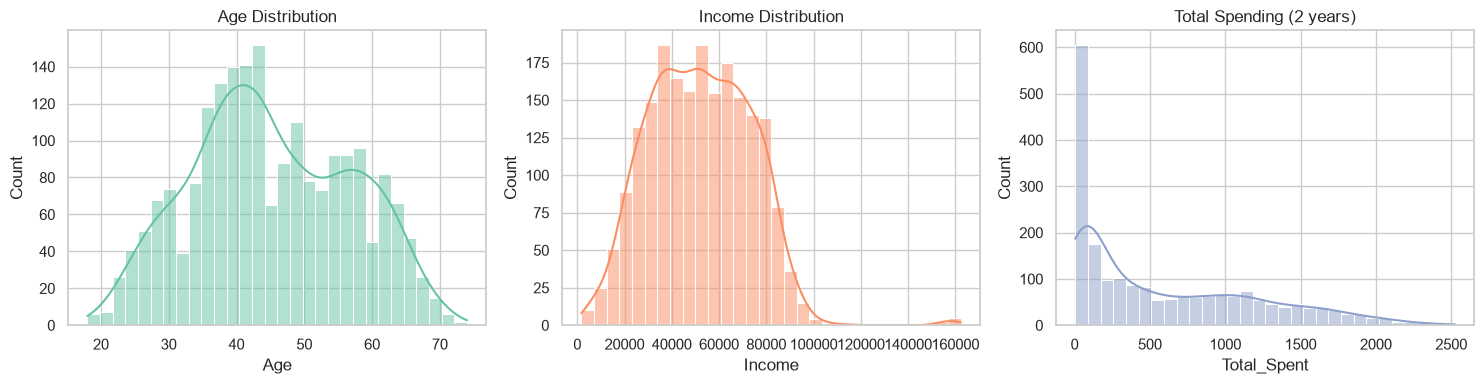

,Age,Income,Total_Spent
mean,45.11,52035.97,606.45
median,44.00,51381.50,397.00
std,11.67,21464.98,602.42
skew,0.10,0.37,0.87


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], bins=30, kde=True, ax=ax[0], color="#66c2a5"); ax[0].set_title("Age Distribution")
sns.histplot(df["Income"], bins=30, kde=True, ax=ax[1], color="#fc8d62"); ax[1].set_title("Income Distribution")
sns.histplot(df["Total_Spent"], bins=30, kde=True, ax=ax[2], color="#8da0cb"); ax[2].set_title("Total Spending (2 years)")
save("02_distributions"); plt.show()
df[["Age", "Income", "Total_Spent"]].agg(["mean", "median", "std", "skew"]).round(2)

**Insight:** Customers are mostly middle-aged (median 44 years, range 18–74). Income is roughly normal around 52,000. **Total spending is strongly right-skewed** – most customers spend little, while a small group spends a lot. That high-value group is the most important to retain.

### 2.2 Customer profile: Education, Marital Status, Children and Response

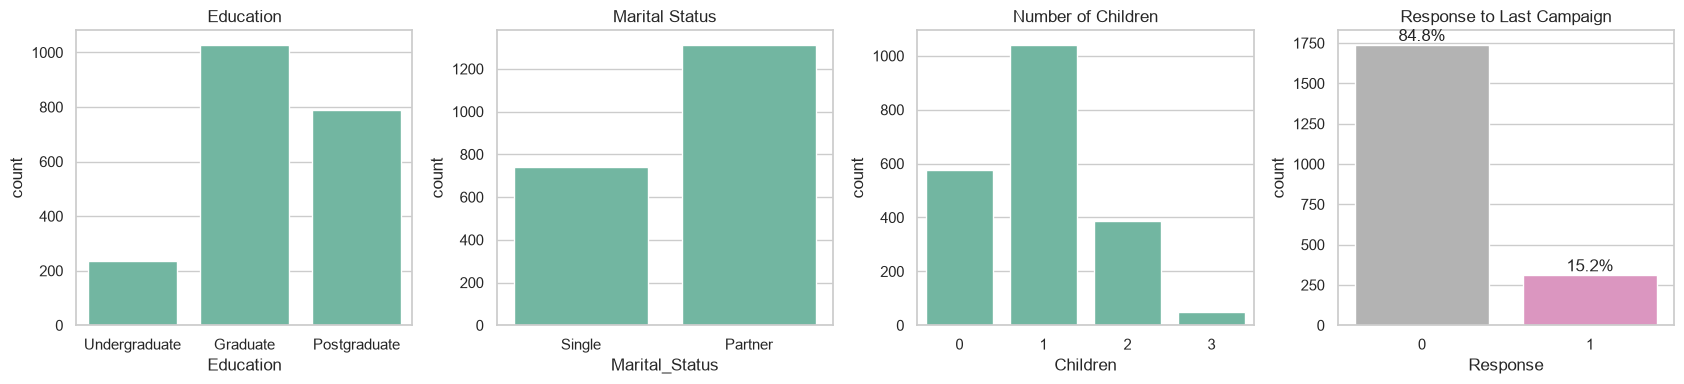

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
sns.countplot(x="Education", data=df, ax=ax[0], order=["Undergraduate", "Graduate", "Postgraduate"]); ax[0].set_title("Education")
sns.countplot(x="Marital_Status", data=df, ax=ax[1]); ax[1].set_title("Marital Status")
sns.countplot(x="Children", data=df, ax=ax[2]); ax[2].set_title("Number of Children")
sns.countplot(x="Response", data=df, ax=ax[3], palette=["#b3b3b3", "#e78ac3"]); ax[3].set_title("Response to Last Campaign")
for p in ax[3].patches:
    ax[3].annotate(f"{p.get_height() / len(df):.1%}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
save("03_customer_profile"); plt.show()

**Insight:** Half the customers are graduates and about 64% live with a partner. Most households have 1 child/teen. **Only 15.2% responded to the last campaign** – the target classes are **imbalanced (85:15)**, which we must handle when building classification models (Step 6).

### 2.3 Income vs Total Spending

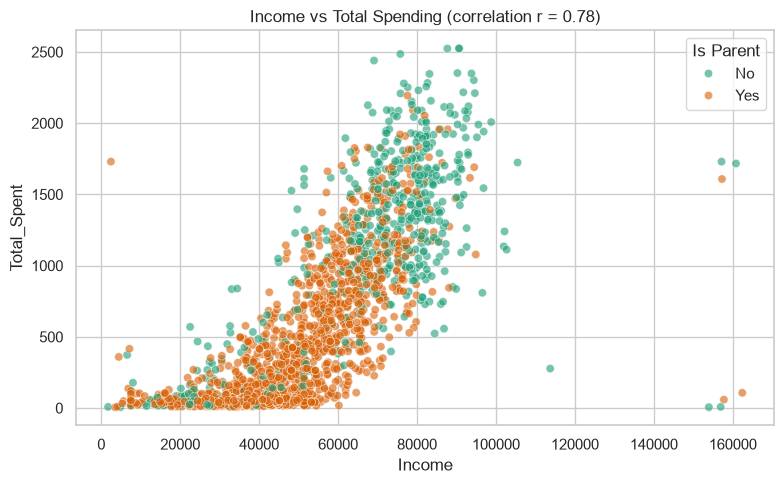

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Income"], y=df["Total_Spent"], hue=df["Is_Parent"].map({0: "No", 1: "Yes"}), alpha=0.6,
                palette={"No": "#1b9e77", "Yes": "#d95f02"})
plt.title(f"Income vs Total Spending (correlation r = {df['Income'].corr(df['Total_Spent']):.2f})")
plt.legend(title="Is Parent")
save("04_income_vs_spending"); plt.show()

**Insight:** There is a **strong positive relationship (r ≈ 0.78)** between income and spending – richer customers spend much more. Non-parents (green) dominate the high-spending region. This relationship is modelled formally with Linear Regression in Step 4.

### 2.4 Spending: Parents vs Non-Parents

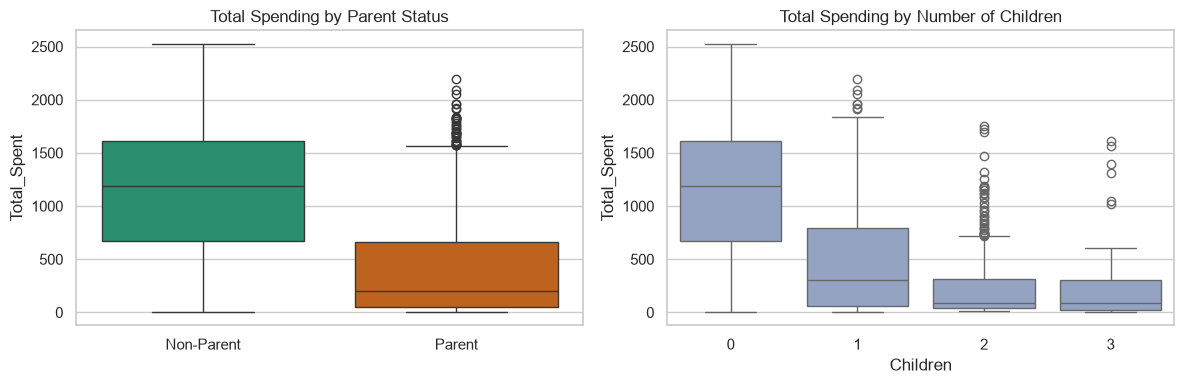

Is_Parent
Non-Parent    1192.5
Parent         202.0
Name: Total_Spent, dtype: float64

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Is_Parent", y="Total_Spent", data=df, ax=ax[0], palette=["#1b9e77", "#d95f02"])
ax[0].set_xticklabels(["Non-Parent", "Parent"]); ax[0].set_title("Total Spending by Parent Status"); ax[0].set_xlabel("")
sns.boxplot(x="Children", y="Total_Spent", data=df, ax=ax[1], color="#8da0cb"); ax[1].set_title("Total Spending by Number of Children")
save("05_spending_parents"); plt.show()
df.groupby("Is_Parent")["Total_Spent"].median().rename({0: "Non-Parent", 1: "Parent"})

**Insight:** Non-parents spend about **6 times more** (median ≈ 1,190 vs ≈ 200). Spending drops steadily as the number of children increases. Families need **discount / value offers**, while customers without children are the premium segment.

### 2.5 Spending by Product Category

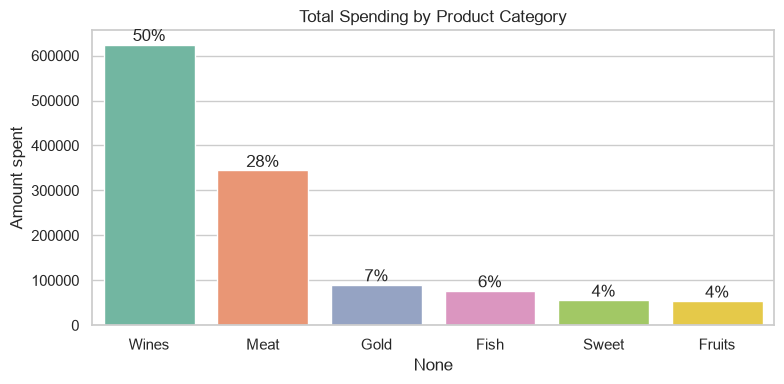

In [13]:
prod = df[utils.MNT_COLS].sum().sort_values(ascending=False)
prod.index = prod.index.str.replace("Mnt", "").str.replace("Products", "").str.replace("Prods", "")
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=prod.index, y=prod.values, palette="Set2")
for i, v in enumerate(prod.values):
    ax.text(i, v, f"{v / prod.sum():.0%}", ha="center", va="bottom")
plt.title("Total Spending by Product Category"); plt.ylabel("Amount spent")
save("06_product_spending"); plt.show()

**Insight:** **Wine (50%) and Meat (28%) make up ~78% of all revenue.** Fruits, sweets and fish together are under 15%. Campaigns should focus on wine and meat offers; smaller categories can be used for cross-selling bundles.

### 2.6 Purchase Channels

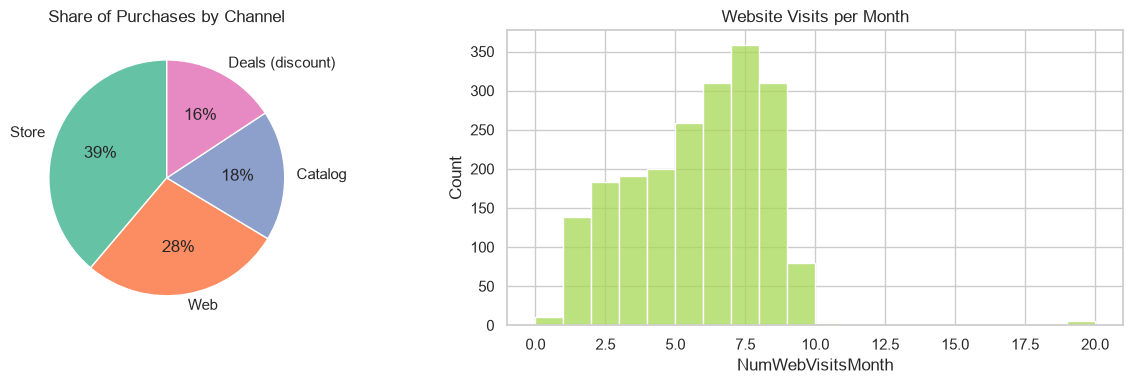

In [14]:
ch = df[["NumStorePurchases", "NumWebPurchases", "NumCatalogPurchases", "NumDealsPurchases"]].sum()
ch.index = ["Store", "Web", "Catalog", "Deals (discount)"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].pie(ch.values, labels=ch.index, autopct="%1.0f%%", startangle=90, colors=sns.color_palette("Set2"))
ax[0].set_title("Share of Purchases by Channel")
sns.histplot(df["NumWebVisitsMonth"], bins=20, ax=ax[1], color="#a6d854"); ax[1].set_title("Website Visits per Month")
save("07_purchase_channels"); plt.show()

**Insight:** **In-store is the main channel (39%)**, followed by Web (28%) and Catalog (18%). About 16% of purchases use a discount. Most customers visit the website 3–7 times a month (median 6), so **online campaigns can reach many customers at low cost**.

### 2.7 Acceptance Rate of Each Campaign

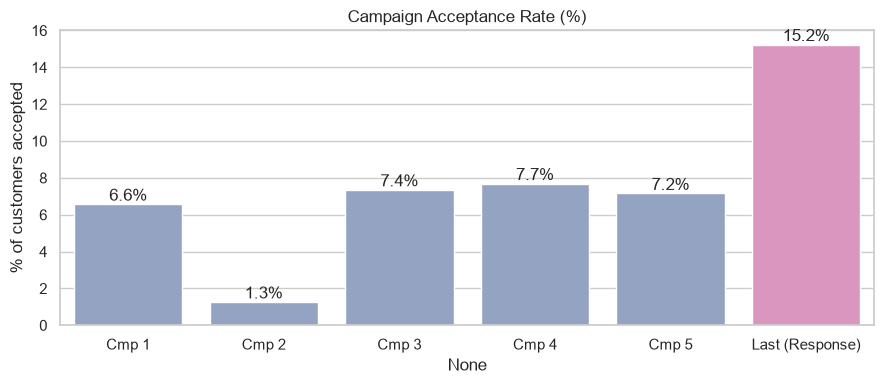

In [15]:
cmp = df[utils.CMP_COLS + ["Response"]].mean() * 100
cmp.index = ["Cmp 1", "Cmp 2", "Cmp 3", "Cmp 4", "Cmp 5", "Last (Response)"]
plt.figure(figsize=(9, 4))
ax = sns.barplot(x=cmp.index, y=cmp.values, palette=["#8da0cb"] * 5 + ["#e78ac3"])
for i, v in enumerate(cmp.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.title("Campaign Acceptance Rate (%)"); plt.ylabel("% of customers accepted")
save("08_campaign_acceptance"); plt.show()

**Insight:** The first five campaigns had very low acceptance (1–8%); **Campaign 2 almost completely failed (1.3%)**. The most recent campaign did better (15.2%) but still **85% of customers were contacted for nothing**. This is exactly the wasted marketing spend that targeted campaigns can reduce.

### 2.8 Correlation Heatmap

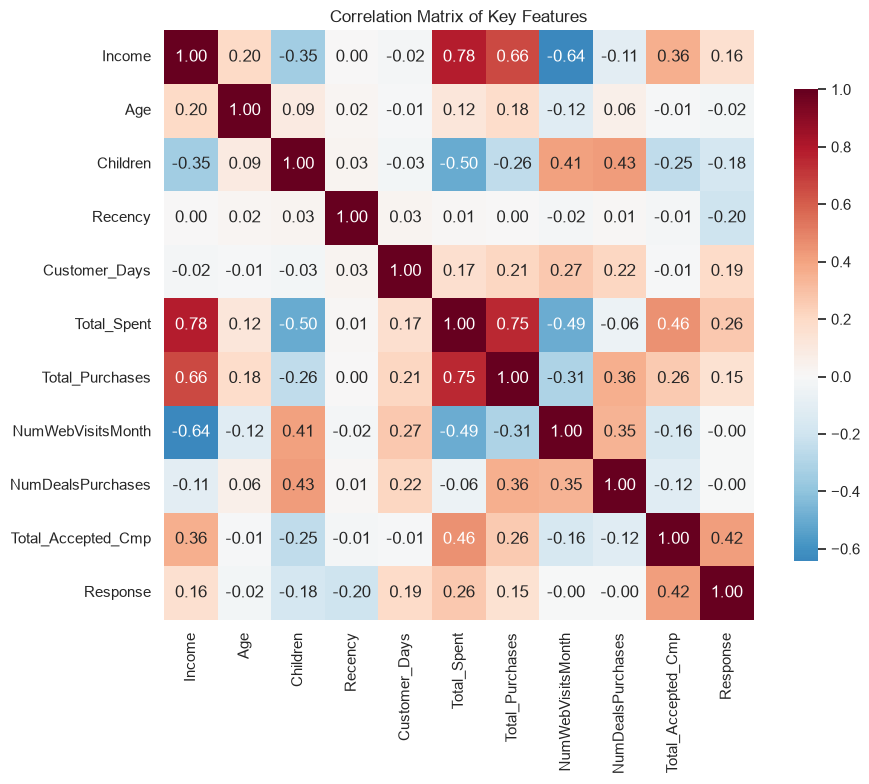

In [16]:
cols = ["Income", "Age", "Children", "Recency", "Customer_Days", "Total_Spent", "Total_Purchases",
        "NumWebVisitsMonth", "NumDealsPurchases", "Total_Accepted_Cmp", "Response"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Key Features")
save("09_correlation_heatmap"); plt.show()

In [17]:
df.select_dtypes("number").corr()["Response"].drop("Response").sort_values(ascending=False).round(3).to_frame("Correlation with Response").head(8)

,Correlation with Response
Total_Accepted_Cmp,0.421
AcceptedCmp5,0.324
AcceptedCmp1,0.292
Total_Spent,0.263
AcceptedCmp3,0.249
MntWines,0.239
MntMeatProducts,0.237
NumCatalogPurchases,0.218


**Insight:** Income, Total_Spent and Total_Purchases are strongly correlated with each other. For **Response**, the strongest positive signal is **Total_Accepted_Cmp (0.42)** – customers who accepted earlier offers tend to accept again. **Recency** and **Children** are negatively related: recent buyers and customers without children respond more.

### 2.9 Who Responds to Campaigns?

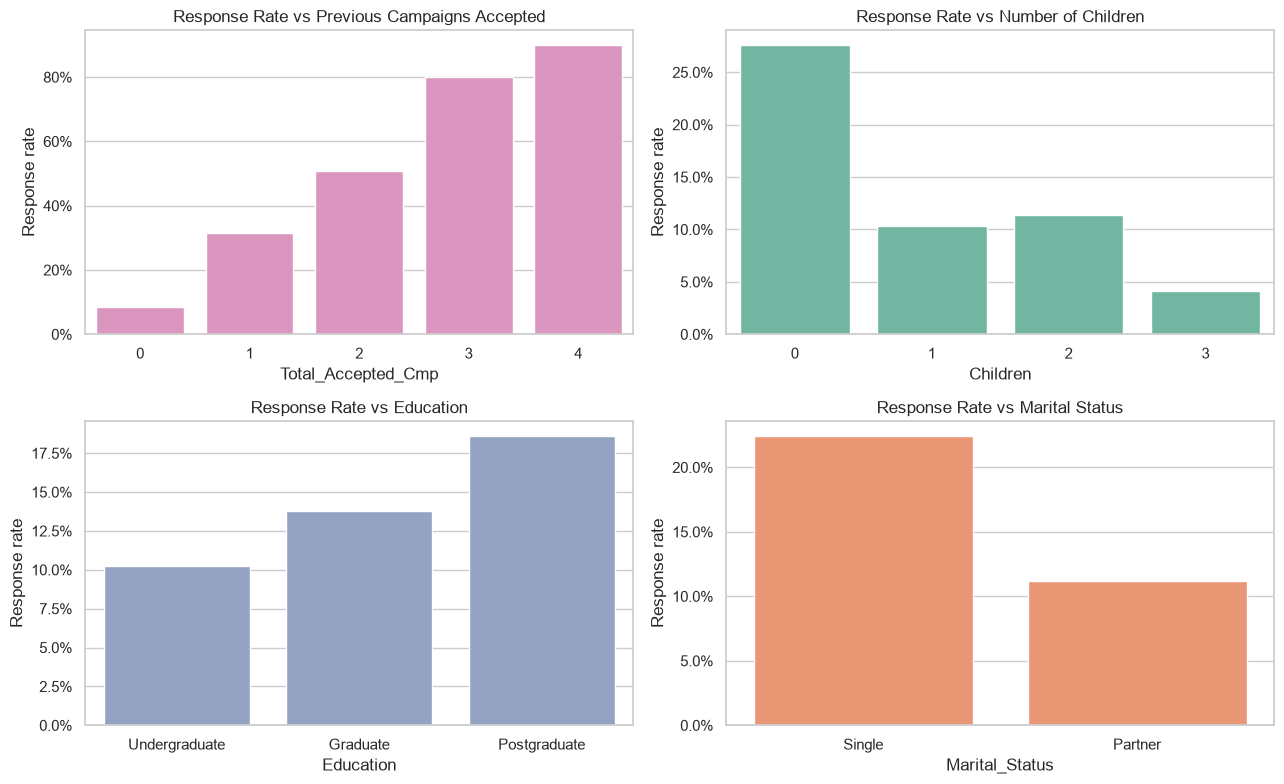

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
sns.barplot(x="Total_Accepted_Cmp", y="Response", data=df, ax=ax[0, 0], errorbar=None, color="#e78ac3")
ax[0, 0].set_title("Response Rate vs Previous Campaigns Accepted")
sns.barplot(x="Children", y="Response", data=df, ax=ax[0, 1], errorbar=None, color="#66c2a5")
ax[0, 1].set_title("Response Rate vs Number of Children")
sns.barplot(x="Education", y="Response", data=df, ax=ax[1, 0], errorbar=None, order=["Undergraduate", "Graduate", "Postgraduate"], color="#8da0cb")
ax[1, 0].set_title("Response Rate vs Education")
sns.barplot(x="Marital_Status", y="Response", data=df, ax=ax[1, 1], errorbar=None, color="#fc8d62")
ax[1, 1].set_title("Response Rate vs Marital Status")
for a in ax.flat:
    a.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0)); a.set_ylabel("Response rate")
save("10_response_drivers"); plt.show()

**Insight:**
- Response rate rises sharply with past acceptances: **8% (0 previous) → 31% (1) → 51% (2) → 80%+ (3–4)**. Loyal responders are the best target.
- Customers **without children respond 28%** of the time vs ~10% for parents.
- **Singles respond twice as often (22%)** as customers living with a partner (11%).
- Postgraduates respond more (19%) than undergraduates (10%).

### 2.10 Responders vs Non-Responders

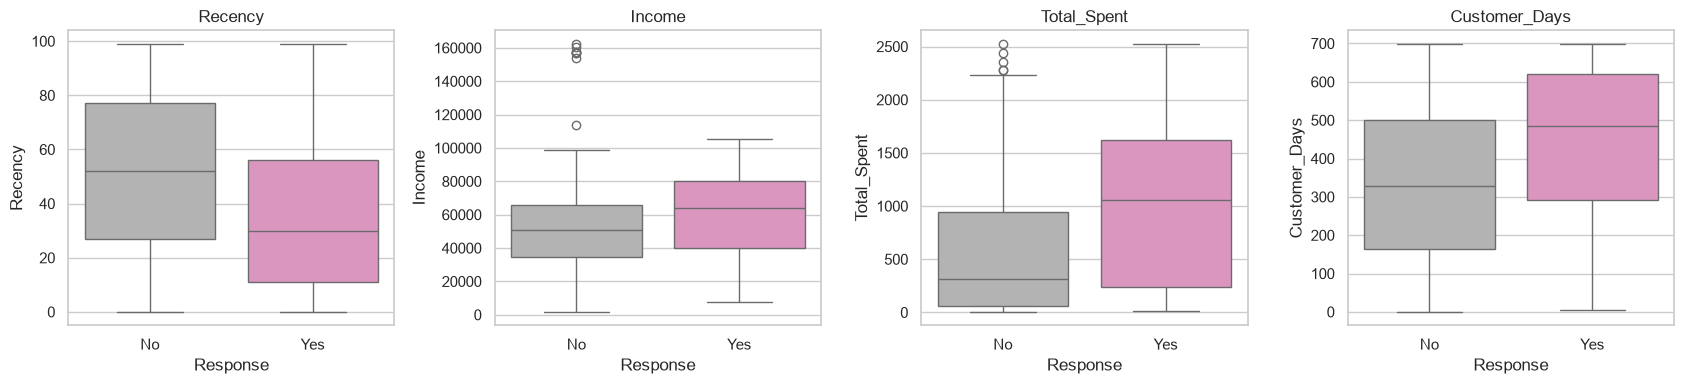

,Recency,Income,Total_Spent,Customer_Days
Response,,,,
No,51.0,50581.0,539.0,336.0
Yes,35.0,60127.0,980.0,443.0


In [19]:
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
for a, col in zip(ax, ["Recency", "Income", "Total_Spent", "Customer_Days"]):
    sns.boxplot(x="Response", y=col, data=df, ax=a, palette=["#b3b3b3", "#e78ac3"])
    a.set_title(col); a.set_xticklabels(["No", "Yes"])
save("11_responders_vs_nonresponders"); plt.show()
df.groupby("Response")[["Recency", "Income", "Total_Spent", "Customer_Days"]].mean().round(0).rename(index={0: "No", 1: "Yes"})

**Insight:** Compared with non-responders, responders **bought more recently** (35 vs 51 days), **earn more** (≈60k vs ≈51k), **spend almost twice as much** (≈980 vs ≈540) and have been **customers for longer** (≈443 vs ≈336 days). Whether these differences are statistically significant is tested in Step 3.

### EDA Summary
1. Spending is driven mainly by **income** and **having no children**.
2. **Wine and meat** generate ~78% of revenue.
3. Only **15%** of customers respond to campaigns → most marketing spend is wasted today.
4. The best responders are **past responders, recent buyers, high spenders, singles and customers without children** – these patterns will be learned automatically by the classification models.

## Step 3: Sampling and Estimation
In real businesses we often cannot survey every customer, so we work with **samples** and **estimate** population values. In this step we:
1. Compute **point estimates** and **95% confidence intervals** (mean spending, mean income, response rate)
2. Show how **sample size** affects the width of a confidence interval
3. Compare **Simple Random Sampling vs Stratified Sampling**
4. Use **Bootstrap resampling** to estimate a confidence interval (Central Limit Theorem demo)
5. Calculate the **sample size** required for a marketing survey
6. Run **hypothesis tests** (t-test, chi-square) to check whether the EDA differences are statistically significant

In [20]:
from scipy import stats
from sklearn.model_selection import train_test_split

def mean_ci(x, conf=0.95):
    x = pd.Series(x).dropna()
    lo, hi = stats.t.interval(conf, len(x) - 1, loc=x.mean(), scale=stats.sem(x))
    return x.mean(), lo, hi

def prop_ci(x, conf=0.95):
    p, n = np.mean(x), len(x)
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    se = np.sqrt(p * (1 - p) / n)
    return p, p - z * se, p + z * se

### 3.1 Point Estimates and 95% Confidence Intervals
- **Mean (t-interval):** x̄ ± t(α/2, n−1) · s/√n
- **Proportion (z-interval):** p̂ ± z(α/2) · √(p̂(1−p̂)/n)

In [21]:
rows = []
for col in ["Total_Spent", "Income", "Age", "Recency"]:
    m, lo, hi = mean_ci(df[col])
    rows.append([f"Mean {col}", m, lo, hi])
p, lo, hi = prop_ci(df["Response"])
rows.append(["Response rate (proportion)", p, lo, hi])
ci_table = pd.DataFrame(rows, columns=["Parameter", "Point Estimate", "95% CI Lower", "95% CI Upper"])
ci_table.round(3)

,Parameter,Point Estimate,95% CI Lower,95% CI Upper
0,Mean Total_Spent,606.446,580.379,632.514
1,Mean Income,52035.971,51107.145,52964.797
2,Mean Age,45.112,44.608,45.617
3,Mean Recency,48.959,47.704,50.214
4,Response rate (proportion),0.152,0.137,0.168


**Interpretation:**
- We are 95% confident that the true **average 2-year spending** of a customer lies between **≈580 and ≈633**.
- We are 95% confident that the true **campaign response rate** lies between **13.7% and 16.8%**.

*Meaning of 95% confidence:* if we repeated the sampling many times, about 95% of the intervals built this way would contain the true population value.

### 3.2 Effect of Sample Size on the Confidence Interval
We draw random samples of different sizes and compute the 95% CI of mean spending for each.

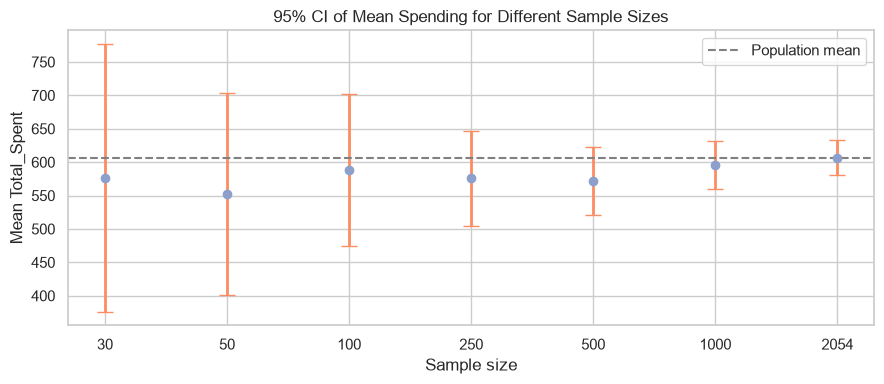

,Sample size,Mean,Lower,Upper,CI width
0,30,576.5,375.8,777.1,401.3
1,50,552.4,400.7,704.1,303.4
2,100,588.2,473.8,702.7,228.9
3,250,575.9,504.6,647.1,142.5
4,500,572.1,521.5,622.7,101.1
5,1000,595.4,559.2,631.7,72.6
6,2054,606.4,580.4,632.5,52.1


In [22]:
sizes = [30, 50, 100, 250, 500, 1000, len(df)]
res = []
for n in sizes:
    s = df["Total_Spent"].sample(n, random_state=1)
    m, lo, hi = mean_ci(s)
    res.append([n, m, lo, hi, hi - lo])
size_df = pd.DataFrame(res, columns=["Sample size", "Mean", "Lower", "Upper", "CI width"])

plt.figure(figsize=(9, 4))
plt.errorbar(size_df["Sample size"].astype(str), size_df["Mean"],
             yerr=[size_df["Mean"] - size_df["Lower"], size_df["Upper"] - size_df["Mean"]],
             fmt="o", capsize=6, color="#8da0cb", ecolor="#fc8d62", lw=2)
plt.axhline(df["Total_Spent"].mean(), ls="--", color="grey", label="Population mean")
plt.title("95% CI of Mean Spending for Different Sample Sizes"); plt.xlabel("Sample size"); plt.ylabel("Mean Total_Spent")
plt.legend(); save("12_ci_vs_sample_size"); plt.show()
size_df.round(1)

**Insight:** As the sample size increases, the confidence interval becomes **much narrower** (width shrinks roughly with 1/√n). Small samples (n = 30) give very uncertain estimates; with ~500 customers the estimate is already quite precise.

### 3.3 Simple Random Sampling vs Stratified Sampling
Response is imbalanced (15% Yes). We draw **200 samples of 300 customers** each way and compare how well each method preserves the true response rate.
- **Simple Random Sampling (SRS):** every customer has an equal chance of selection.
- **Stratified Sampling:** the population is split into strata (Response = 0 / 1) and each stratum is sampled in proportion.

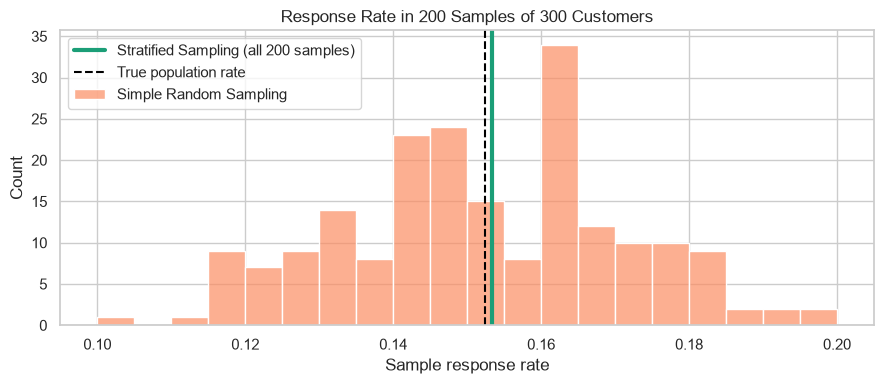

,Method,Mean response rate,Std deviation,Min,Max
0,Simple Random,0.1519,0.0187,0.1000,0.2000
1,Stratified,0.1533,0.0000,0.1533,0.1533


In [23]:
srs_rates, strat_rates = [], []
for i in range(200):
    srs_rates.append(df.sample(300, random_state=i)["Response"].mean())
    _, s = train_test_split(df, test_size=300, stratify=df["Response"], random_state=i)
    strat_rates.append(s["Response"].mean())

plt.figure(figsize=(9, 4))
sns.histplot(srs_rates, bins=20, color="#fc8d62", label="Simple Random Sampling", alpha=0.7)
plt.axvline(np.mean(strat_rates), color="#1b9e77", lw=3, label="Stratified Sampling (all 200 samples)")
plt.axvline(df["Response"].mean(), color="black", ls="--", label="True population rate")
plt.title("Response Rate in 200 Samples of 300 Customers"); plt.xlabel("Sample response rate")
plt.legend(); save("13_srs_vs_stratified"); plt.show()

pd.DataFrame({"Method": ["Simple Random", "Stratified"],
              "Mean response rate": [np.mean(srs_rates), np.mean(strat_rates)],
              "Std deviation": [np.std(srs_rates), np.std(strat_rates)],
              "Min": [np.min(srs_rates), np.min(strat_rates)],
              "Max": [np.max(srs_rates), np.max(strat_rates)]}).round(4)

**Insight:** With simple random sampling the response rate in a sample varied from **10% to 20%** just by chance. **Stratified sampling kept it at ≈15.3% every time** (zero variation). This is why we use **stratified train/test splitting** (`stratify=y`) for the classification models in Step 6 – both training and testing sets will have the same 15% responders.

### 3.4 Bootstrap Confidence Interval and the Central Limit Theorem
Bootstrap = resample the data **with replacement** many times, compute the mean each time, and use the spread of those means to estimate the confidence interval. It does not assume any distribution.

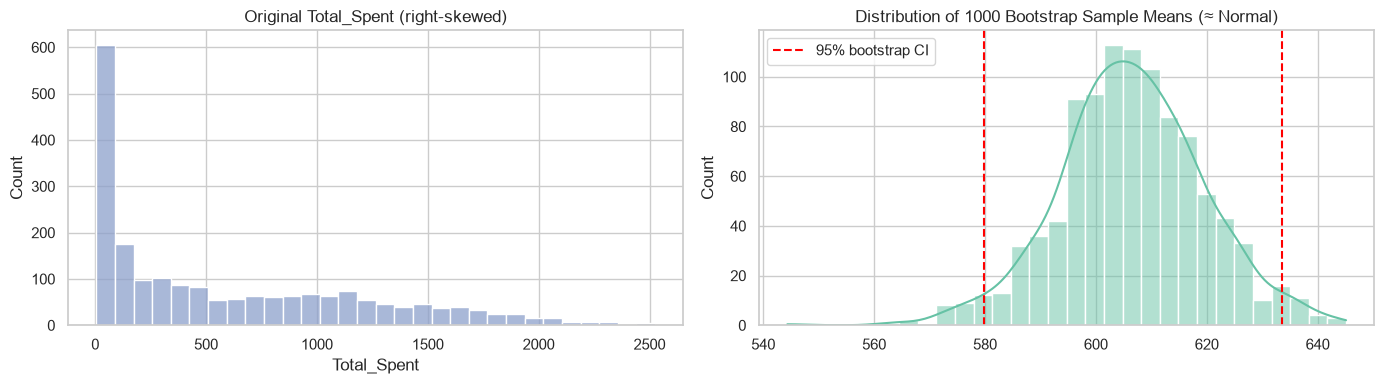

Bootstrap 95% CI : (579.7, 633.5)
t-based 95% CI   : (580.4, 632.5)


In [24]:
boot_means = [df["Total_Spent"].sample(len(df), replace=True, random_state=i).mean() for i in range(1000)]
b_lo, b_hi = np.percentile(boot_means, [2.5, 97.5])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["Total_Spent"], bins=30, ax=ax[0], color="#8da0cb")
ax[0].set_title("Original Total_Spent (right-skewed)")
sns.histplot(boot_means, bins=30, kde=True, ax=ax[1], color="#66c2a5")
ax[1].axvline(b_lo, color="red", ls="--"); ax[1].axvline(b_hi, color="red", ls="--", label="95% bootstrap CI")
ax[1].set_title("Distribution of 1000 Bootstrap Sample Means (≈ Normal)"); ax[1].legend()
save("14_bootstrap_clt"); plt.show()

t_mean, t_lo, t_hi = mean_ci(df["Total_Spent"])
print(f"Bootstrap 95% CI : ({b_lo:.1f}, {b_hi:.1f})")
print(f"t-based 95% CI   : ({t_lo:.1f}, {t_hi:.1f})")

**Insight:** Even though spending itself is heavily skewed, the **distribution of sample means is bell-shaped (normal)** – this is the **Central Limit Theorem**. The bootstrap CI (≈580–633) almost exactly matches the t-based CI, confirming our estimate.

### 3.5 Sample Size Planning for a Marketing Survey
Suppose the company wants to estimate the response rate of a new campaign through a pilot test. How many customers must be contacted to estimate it within a margin of error **E**?

**Formula:** n = z² · p(1−p) / E²  (using p = 0.152 from past data)

In [25]:
p0 = df["Response"].mean()
plan = []
for conf in [0.90, 0.95, 0.99]:
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    for E in [0.05, 0.03, 0.02]:
        plan.append([f"{conf:.0%}", f"±{E:.0%}", int(np.ceil(z**2 * p0 * (1 - p0) / E**2))])
pd.DataFrame(plan, columns=["Confidence", "Margin of error", "Required sample size"]).pivot(
    index="Confidence", columns="Margin of error", values="Required sample size")

Margin of error,±2%,±3%,±5%
Confidence,,,
90%,874,389,140
95%,1241,552,199
99%,2143,953,343


**Insight:** To estimate the response rate within **±3% at 95% confidence**, a pilot campaign needs only **≈550 customers**, not the whole customer base. Higher confidence or a smaller margin of error needs a bigger sample.

### 3.6 Hypothesis Testing
We test whether the differences seen in the EDA are **real (statistically significant)** or due to chance. Significance level **α = 0.05**.

**(a) Welch two-sample t-test** – numeric variables, responders vs non-responders
- H₀: mean of the variable is the same for responders and non-responders
- H₁: the means are different

In [26]:
t_rows = []
for col in ["Total_Spent", "Income", "Recency", "Customer_Days", "Age", "NumWebVisitsMonth"]:
    yes, no = df.loc[df["Response"] == 1, col], df.loc[df["Response"] == 0, col]
    t, pval = stats.ttest_ind(yes, no, equal_var=False)
    t_rows.append([col, yes.mean(), no.mean(), t, pval, "Reject H₀ (significant)" if pval < 0.05 else "Fail to reject H₀"])
pd.DataFrame(t_rows, columns=["Variable", "Mean (Responders)", "Mean (Non-responders)", "t-statistic", "p-value", "Decision"]).round(4)

,Variable,Mean (Responders),Mean (Non-responders),t-statistic,p-value,Decision
0,Total_Spent,979.9872,539.2906,10.3247,0.0000,Reject H₀ (significant)
1,Income,60127.1805,50581.3191,6.8288,0.0000,Reject H₀ (significant)
2,Recency,35.0639,51.4572,-9.6819,0.0000,Reject H₀ (significant)
3,Customer_Days,442.9617,336.4383,8.6872,0.0000,Reject H₀ (significant)
4,Age,44.4760,45.2269,-0.9976,0.3191,Fail to reject H₀
5,NumWebVisitsMonth,5.3035,5.3257,-0.1418,0.8873,Fail to reject H₀


**(b) Chi-square test of independence** – categorical variables vs Response
- H₀: the variable and Response are independent
- H₁: they are associated

In [27]:
c_rows = []
for col in ["Education", "Marital_Status", "Is_Parent", "Complain"]:
    chi2, pval, dof, _ = stats.chi2_contingency(pd.crosstab(df[col], df["Response"]))
    c_rows.append([col, chi2, dof, pval, "Reject H₀ (associated)" if pval < 0.05 else "Fail to reject H₀"])
pd.DataFrame(c_rows, columns=["Variable", "Chi-square", "df", "p-value", "Decision"]).round(4)

,Variable,Chi-square,df,p-value,Decision
0,Education,13.1868,2,0.0014,Reject H₀ (associated)
1,Marital_Status,45.4803,1,0.0000,Reject H₀ (associated)
2,Is_Parent,93.4369,1,0.0000,Reject H₀ (associated)
3,Complain,0.0000,1,1.0000,Fail to reject H₀


**Insight:**
- Responders **spend significantly more**, **earn more**, **bought more recently** and have been **customers longer** (all p < 0.001). The EDA differences are real, not random.
- **Education, Marital Status and Parent status are all significantly associated** with Response (p < 0.01).
- **Age (p = 0.32) and website visits (p = 0.89) do NOT differ significantly** – responders are not younger or more active online.
- **Complain has no relationship** with Response (p = 1.0), so it is a weak predictor.

### Sampling & Estimation Summary
1. Average customer spending is **606 (95% CI: 580–633)**; response rate is **15.2% (95% CI: 13.7%–16.8%)**.
2. Larger samples give narrower, more reliable estimates.
3. **Stratified sampling** preserves the response ratio exactly – used for the train/test split in Step 6.
4. The bootstrap confirms the CI and demonstrates the **Central Limit Theorem**.
5. A pilot campaign of **~550 customers** is enough to estimate response within ±3%.
6. Hypothesis tests confirm that spending, income, recency, tenure, marital status and children **significantly** influence response.

## Step 4: Linear Regression – Predicting Customer Spending
**Business question:** *Can we estimate how much a customer will spend from their profile alone?*
This helps the company estimate the **value of a new customer** before they have bought much.

- **Target (y):** `Total_Spent` (2-year spending)
- **Features (X):** Income, Age, Children, Partner, Education, Recency, Customer_Days, NumWebVisitsMonth
- The spending (`Mnt*`) and purchase-count columns are **not used as features**, because Total_Spent is built from them (that would leak the answer).

We build (1) a **Simple Linear Regression** with Income only, and (2) a **Multiple Linear Regression** with all features.

In [28]:
import statsmodels.api as sm
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_lr = df[utils.LINREG_FEATURES]
y_lr = df["Total_Spent"]
X_tr, X_te, y_tr, y_te = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)
print("Train:", X_tr.shape, "| Test:", X_te.shape)

def reg_metrics(y_true, y_pred):
    return {"R²": r2_score(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "MAE": mean_absolute_error(y_true, y_pred)}

Train: (1643, 8) | Test: (411, 8)


### 4.1 Simple Linear Regression: Total_Spent = β₀ + β₁ · Income

Equation: Total_Spent = -528.75 + 0.02182 × Income
{'R²': 0.631, 'RMSE': 382.691, 'MAE': 285.121}


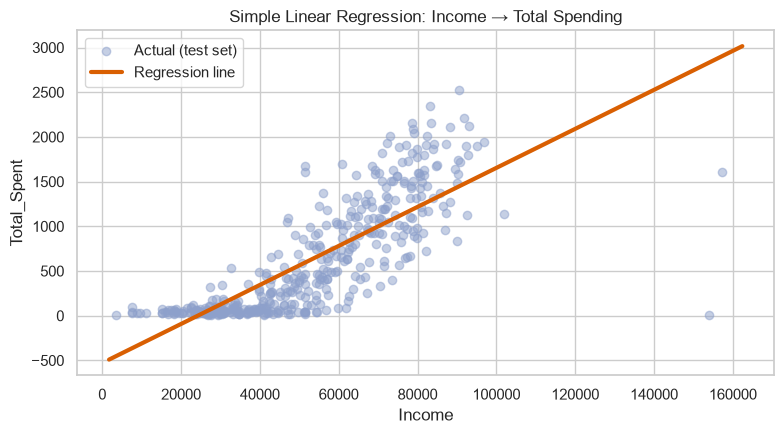

In [29]:
slr = LinearRegression().fit(X_tr[["Income"]], y_tr)
slr_pred = slr.predict(X_te[["Income"]])
print(f"Equation: Total_Spent = {slr.intercept_:.2f} + {slr.coef_[0]:.5f} × Income")
print({k: round(v, 3) for k, v in reg_metrics(y_te, slr_pred).items()})

plt.figure(figsize=(8, 4.5))
plt.scatter(X_te["Income"], y_te, alpha=0.5, color="#8da0cb", label="Actual (test set)")
xs = np.linspace(X_lr["Income"].min(), X_lr["Income"].max(), 100)
plt.plot(xs, slr.predict(pd.DataFrame({"Income": xs})), color="#d95f02", lw=3, label="Regression line")
plt.xlabel("Income"); plt.ylabel("Total_Spent"); plt.title("Simple Linear Regression: Income → Total Spending")
plt.legend(); save("15_simple_linear_regression"); plt.show()

**Interpretation:** Every additional **1,000 of income increases 2-year spending by ≈ 22**. Income alone explains about **63% of the variation** in spending (R² ≈ 0.63).

### 4.2 Multiple Linear Regression

In [30]:
mlr = LinearRegression().fit(X_tr, y_tr)
mlr_pred = mlr.predict(X_te)
cv_r2 = cross_val_score(LinearRegression(), X_lr, y_lr, cv=5, scoring="r2")

comparison = pd.DataFrame([reg_metrics(y_te, slr_pred), reg_metrics(y_te, mlr_pred)],
                          index=["Simple LR (Income only)", "Multiple LR (8 features)"]).round(3)
comparison["5-fold CV R² (mean)"] = [cross_val_score(LinearRegression(), X_lr[["Income"]], y_lr, cv=5, scoring="r2").mean().round(3),
                                     cv_r2.mean().round(3)]
comparison

,R²,RMSE,MAE,5-fold CV R² (mean)
Simple LR (Income only),0.631,382.691,285.121,0.609
Multiple LR (8 features),0.712,338.168,247.460,0.699


**Insight:** Adding the other customer attributes raises R² from **0.63 to ≈ 0.71** and reduces the average error (RMSE) from ≈ 383 to ≈ 338. 5-fold cross-validation gives a similar R² (≈ 0.70), so the model is **stable and not overfitting**.

### 4.3 Regression Coefficients and Significance (OLS summary)
We fit the same model with `statsmodels` to obtain **p-values** for each coefficient (H₀: βᵢ = 0).

In [31]:
ols = sm.OLS(y_tr, sm.add_constant(X_tr)).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Spent   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     478.8
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:56:29   Log-Likelihood:                -11836.
No. Observations:                1643   AIC:                         2.369e+04
Df Residuals:                    1634   BIC:                         2.374e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -465.6103     55.84

In [32]:
coef_table = pd.DataFrame({"Coefficient": ols.params, "Std Error": ols.bse,
                           "t-value": ols.tvalues, "p-value": ols.pvalues}).drop("const")
coef_table["Significant (p<0.05)"] = np.where(coef_table["p-value"] < 0.05, "Yes", "No")
coef_table.round(4)

,Coefficient,Std Error,t-value,p-value,Significant (p<0.05)
Income,0.0200,0.0005,38.5909,0.0000,Yes
Age,0.0957,0.7323,0.1307,0.8960,No
Children,-216.6102,12.2358,-17.7030,0.0000,Yes
Partner,-8.1419,16.8322,-0.4837,0.6287,No
Edu_Code,-1.6244,12.8318,-0.1266,0.8993,No
Recency,0.4017,0.2786,1.4418,0.1495,No
Customer_Days,0.4834,0.0429,11.2735,0.0000,Yes
NumWebVisitsMonth,9.9585,4.7221,2.1089,0.0351,Yes


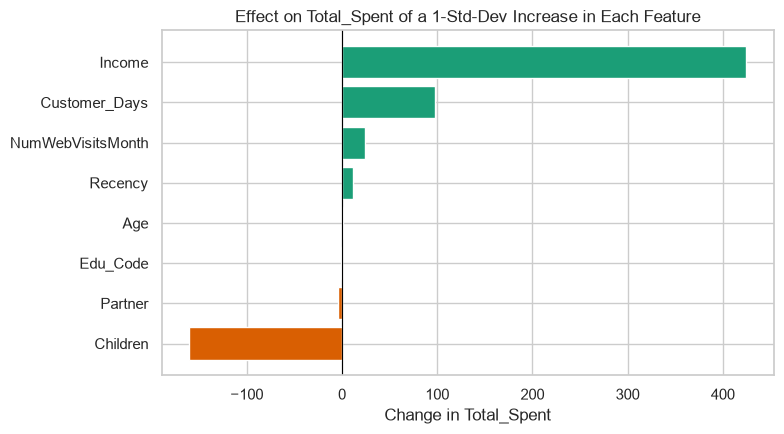

In [33]:
# Standardized coefficients: effect of a 1 standard-deviation change in each feature (comparable across features)
std_coef = (pd.Series(mlr.coef_, index=utils.LINREG_FEATURES) * X_tr.std()).sort_values()
plt.figure(figsize=(8, 4.5))
plt.barh(std_coef.index, std_coef.values, color=["#d95f02" if v < 0 else "#1b9e77" for v in std_coef.values])
plt.axvline(0, color="black", lw=0.8)
plt.title("Effect on Total_Spent of a 1-Std-Dev Increase in Each Feature"); plt.xlabel("Change in Total_Spent")
save("16_regression_coefficients"); plt.show()

**Interpretation of the coefficients** (holding other features constant):
- **Income** is the strongest driver: +1,000 income → **≈ +20** spending.
- **Children**: each additional child/teen **reduces spending by ≈ 217** – the largest negative effect.
- **Customer_Days**: each extra day as a customer adds ≈ 0.5, i.e. **≈ +175 per year** of membership – loyal customers spend more.
- **NumWebVisitsMonth** has a small positive effect (≈ +10 per monthly visit).
- **Age, Partner, Education and Recency are not significant** (p > 0.05) once income and children are known.

### 4.4 Model Diagnostics – Actual vs Predicted and Residuals
Linear regression assumes the errors (residuals) are random, centred at zero and roughly normal.

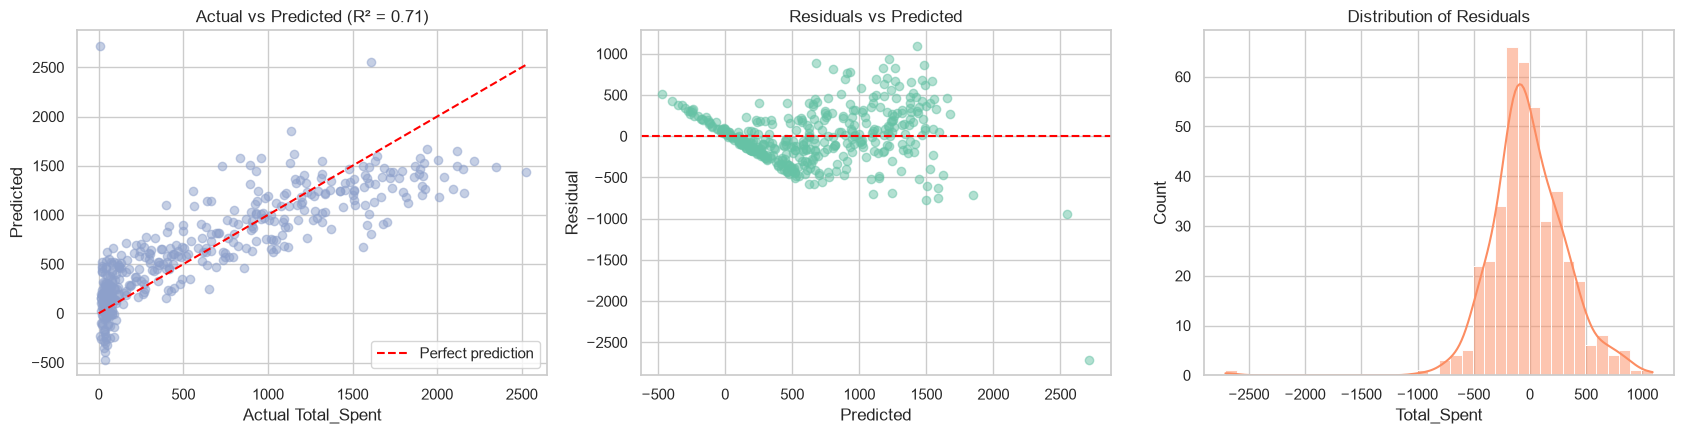

Mean residual: -8.29 | Negative predictions in test set: 37


In [34]:
resid = y_te - mlr_pred
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(y_te, mlr_pred, alpha=0.5, color="#8da0cb")
lim = [0, y_lr.max()]
ax[0].plot(lim, lim, "r--", label="Perfect prediction"); ax[0].legend()
ax[0].set_xlabel("Actual Total_Spent"); ax[0].set_ylabel("Predicted"); ax[0].set_title(f"Actual vs Predicted (R² = {r2_score(y_te, mlr_pred):.2f})")
ax[1].scatter(mlr_pred, resid, alpha=0.5, color="#66c2a5"); ax[1].axhline(0, color="red", ls="--")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual"); ax[1].set_title("Residuals vs Predicted")
sns.histplot(resid, kde=True, ax=ax[2], color="#fc8d62"); ax[2].set_title("Distribution of Residuals")
save("17_regression_diagnostics"); plt.show()
print("Mean residual:", round(resid.mean(), 2), "| Negative predictions in test set:", int((mlr_pred < 0).sum()))

**Diagnostics:**
- Residuals are centred around zero and bell-shaped, though with heavier tails than a normal distribution (a few customers spend far more/less than their profile suggests).
- The *large condition number* warning in the OLS summary is caused by the different scales of the features (Income is in tens of thousands), not by real multicollinearity.
- The residual spread **widens for larger predictions** (heteroscedasticity): high-income customers vary more in how much they spend.
- The **curved pattern at low predictions** shows the income–spending relationship is not perfectly linear (spending stays near zero for low incomes, then rises quickly).
- One outlier (very high income but almost no spending) gives the large negative residual of ≈ −2,700.
- For some low-income customers the model predicts slightly **negative spending**, which is impossible – in the dashboard predictions are therefore **clipped at 0**.
- *Possible improvement:* model log(Total_Spent) or use a non-linear model (e.g. Random Forest Regressor).

### 4.5 Example Prediction and Saving the Model

In [35]:
example = pd.DataFrame([{"Income": 75000, "Age": 40, "Children": 0, "Partner": 1, "Edu_Code": 1,
                         "Recency": 20, "Customer_Days": 500, "NumWebVisitsMonth": 4},
                        {"Income": 35000, "Age": 40, "Children": 2, "Partner": 1, "Edu_Code": 1,
                         "Recency": 20, "Customer_Days": 500, "NumWebVisitsMonth": 7}])
example["Predicted_Total_Spent"] = np.clip(mlr.predict(example[utils.LINREG_FEATURES]), 0, None).round(0)
display(example)

joblib.dump(mlr, "models/linreg.pkl")
print("Saved -> models/linreg.pkl")

,Income,Age,Children,Partner,Edu_Code,Recency,Customer_Days,NumWebVisitsMonth,Predicted_Total_Spent
0,75000,40,0,1,1,20,500,4,1318.0
1,35000,40,2,1,1,20,500,7,114.0


Saved -> models/linreg.pkl


**Linear Regression Summary**
- **Multiple Linear Regression explains ≈ 71% of the variation** in customer spending (test R² ≈ 0.71, CV R² ≈ 0.70).
- **Income (+) and number of children (−)** are the dominant drivers; customer tenure also increases spending.
- Example: a high-income customer without children is predicted to spend **≈ 1,318 vs ≈ 114** – more than **10× more** than a lower-income parent of two – the company should prioritise premium offers for the first group and value offers for the second.

## Step 5: Customer Segmentation using K-Means Clustering
**Business question:** *What natural groups of customers exist, and how should marketing treat each group?*

K-Means is an **unsupervised** algorithm: it groups customers that are similar to each other without using the Response label.

**Features used:** Income, Total_Spent, Age, Children, Total_Purchases, Recency, NumWebVisitsMonth
All features are **standardised** (mean 0, std 1) first, because K-Means uses distances and Income (tens of thousands) would otherwise dominate.

In [36]:
import importlib; importlib.reload(utils)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X_km = df[utils.CLUSTER_FEATURES]
km_scaler = StandardScaler().fit(X_km)
X_km_s = km_scaler.transform(X_km)
pd.DataFrame(X_km_s, columns=utils.CLUSTER_FEATURES).describe().loc[["mean", "std"]].round(2)

,Income,Total_Spent,Age,Children,Total_Purchases,Recency,NumWebVisitsMonth
mean,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 5.1 Choosing the Number of Clusters (k)
- **Elbow method:** plot the within-cluster sum of squares (inertia) for each k and look for the "elbow" where improvement slows down.
- **Silhouette score:** measures how well each customer fits its own cluster compared with the nearest other cluster (−1 to 1, higher is better).

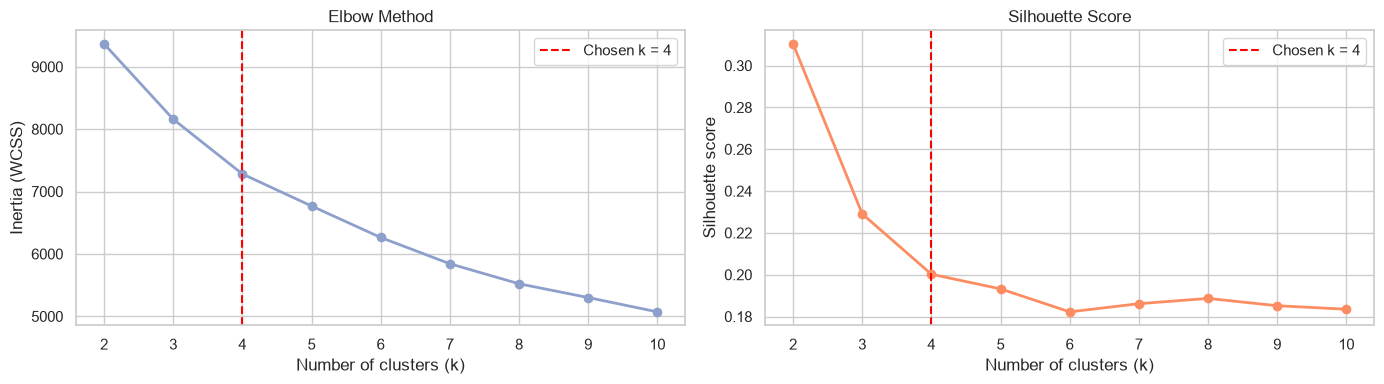

k,2,3,4,5,6,7,8,9,10
Inertia,9366.00,8159.000,7281.0,6768.000,6264.000,5843.000,5522.000,5301.000,5071.000
Silhouette,0.31,0.229,0.2,0.193,0.182,0.186,0.189,0.185,0.183


In [37]:
k_range = range(2, 11)
inertia, sil = [], []
for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_km_s)
    inertia.append(km_k.inertia_)
    sil.append(silhouette_score(X_km_s, km_k.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(k_range), inertia, "o-", color="#8da0cb", lw=2); ax[0].axvline(4, color="red", ls="--", label="Chosen k = 4")
ax[0].set_title("Elbow Method"); ax[0].set_xlabel("Number of clusters (k)"); ax[0].set_ylabel("Inertia (WCSS)"); ax[0].legend()
ax[1].plot(list(k_range), sil, "o-", color="#fc8d62", lw=2); ax[1].axvline(4, color="red", ls="--", label="Chosen k = 4")
ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("Number of clusters (k)"); ax[1].set_ylabel("Silhouette score"); ax[1].legend()
save("18_elbow_silhouette"); plt.show()
pd.DataFrame({"k": list(k_range), "Inertia": np.round(inertia), "Silhouette": np.round(sil, 3)}).set_index("k").T

**Choosing k = 4:**
- The elbow curve bends around **k = 4**: the drop in inertia shrinks from ≈1,200 (k 2→3) and ≈880 (3→4) to only ≈510 (4→5) and less afterwards.
- k = 2 has the highest silhouette, but it only splits customers into "high" and "low" spenders, which is **too simple for targeted marketing**.
- From k = 4 onwards the silhouette score is almost flat (≈ 0.18–0.20), so k = 4 gives **more useful segments without losing much cluster quality**.

A silhouette of ≈ 0.2 is typical for real customer data, where customers form a continuum rather than perfectly separate groups.

### 5.2 Fitting K-Means with k = 4

In [38]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_km_s)
df["Cluster"] = kmeans.labels_

profile = df.groupby("Cluster")[utils.CLUSTER_FEATURES].mean()
cluster_names = utils.name_clusters(profile)
df["Segment"] = df["Cluster"].map(cluster_names)
seg_order = ["Premium Spenders", "Established Families", "Budget Families", "Young Starters"]
seg_colors = dict(zip(seg_order, ["#1b9e77", "#7570b3", "#d95f02", "#e7298a"]))
print("Cluster names:", cluster_names)
df["Segment"].value_counts().reindex(seg_order).to_frame("Customers")

Cluster names: {3: 'Premium Spenders', 1: 'Established Families', 0: 'Budget Families', 2: 'Young Starters'}


,Customers
Segment,
Premium Spenders,453
Established Families,585
Budget Families,432
Young Starters,584


### 5.3 Visualising the Clusters with PCA
The data has 7 dimensions, so we use **Principal Component Analysis (PCA)** to project it onto 2 dimensions for plotting.

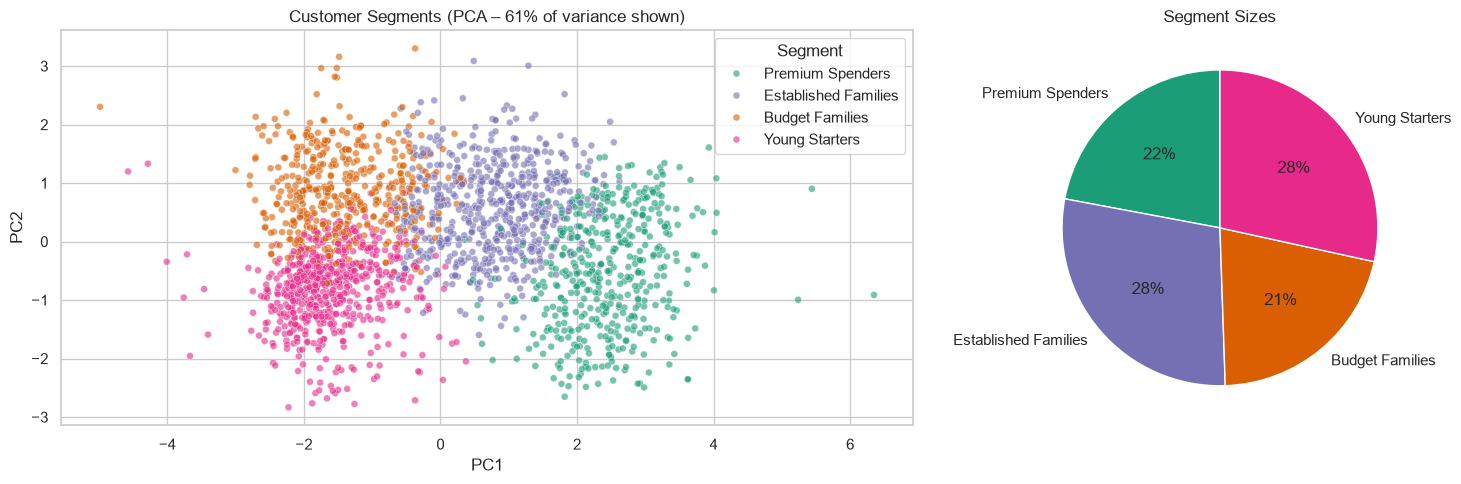

In [39]:
pca = PCA(n_components=2, random_state=42).fit(X_km_s)
pcs = pca.transform(X_km_s)
df["PC1"], df["PC2"] = pcs[:, 0], pcs[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2, 1]})
sns.scatterplot(x="PC1", y="PC2", hue="Segment", data=df, palette=seg_colors, hue_order=seg_order, alpha=0.6, s=25, ax=ax[0])
ax[0].set_title(f"Customer Segments (PCA – {pca.explained_variance_ratio_.sum():.0%} of variance shown)")
sizes = df["Segment"].value_counts().reindex(seg_order)
ax[1].pie(sizes, labels=sizes.index, autopct="%1.0f%%", colors=[seg_colors[s] for s in seg_order], startangle=90)
ax[1].set_title("Segment Sizes")
save("19_clusters_pca"); plt.show()

**Insight:** The four segments occupy clearly different regions of the PCA plot, and they are **similar in size (21–29% each)**, so each is large enough to target with its own campaign. The first two principal components capture about 60% of the information in the 7 features.

### 5.4 Segment Profiles

In [40]:
prof_cols = ["Income", "Total_Spent", "Age", "Children", "Kidhome", "Teenhome", "Total_Purchases",
             "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
             "NumWebVisitsMonth", "Recency", "Customer_Days", "Total_Accepted_Cmp", "Response"]
seg_profile = df.groupby("Segment")[prof_cols].mean().reindex(seg_order)
seg_profile.insert(0, "Customers", df["Segment"].value_counts().reindex(seg_order))
seg_profile.T.round(2)

Segment,Premium Spenders,Established Families,Budget Families,Young Starters
Customers,453.00,585.00,432.00,584.00
Income,78354.37,60588.92,41975.15,30495.84
Total_Spent,1389.24,847.12,128.03,112.05
Age,45.08,49.55,50.39,36.79
Children,0.08,1.07,1.89,0.83
Kidhome,0.01,0.19,0.87,0.72
Teenhome,0.07,0.88,1.02,0.11
Total_Purchases,20.00,21.81,9.34,8.07
NumDealsPurchases,1.09,3.51,2.61,1.94
NumWebPurchases,4.81,6.52,2.45,2.35


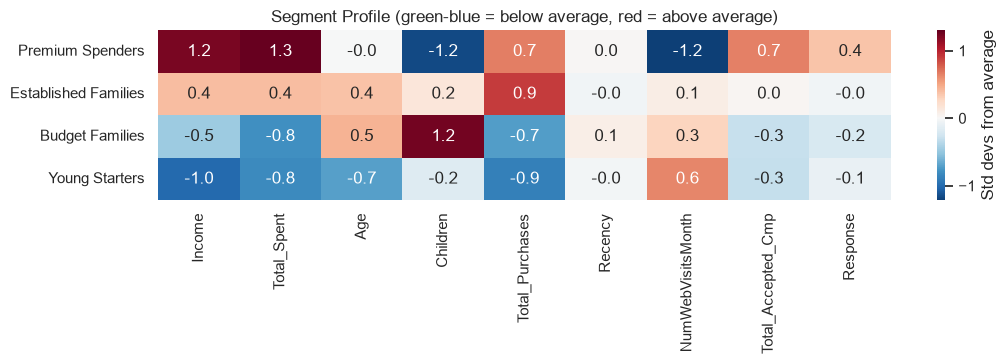

In [41]:
# Heatmap: each feature compared with the overall average (z-score of segment means)
z = (df.groupby("Segment")[utils.CLUSTER_FEATURES + ["Total_Accepted_Cmp", "Response"]].mean().reindex(seg_order)
     - df[utils.CLUSTER_FEATURES + ["Total_Accepted_Cmp", "Response"]].mean()) / df[utils.CLUSTER_FEATURES + ["Total_Accepted_Cmp", "Response"]].std()
plt.figure(figsize=(11, 3.8))
sns.heatmap(z, annot=True, fmt=".1f", cmap="RdBu_r", center=0, cbar_kws={"label": "Std devs from average"})
plt.title("Segment Profile (green-blue = below average, red = above average)"); plt.ylabel("")
save("20_segment_profile_heatmap"); plt.show()

### 5.5 Spending, Channels and Campaign Response by Segment

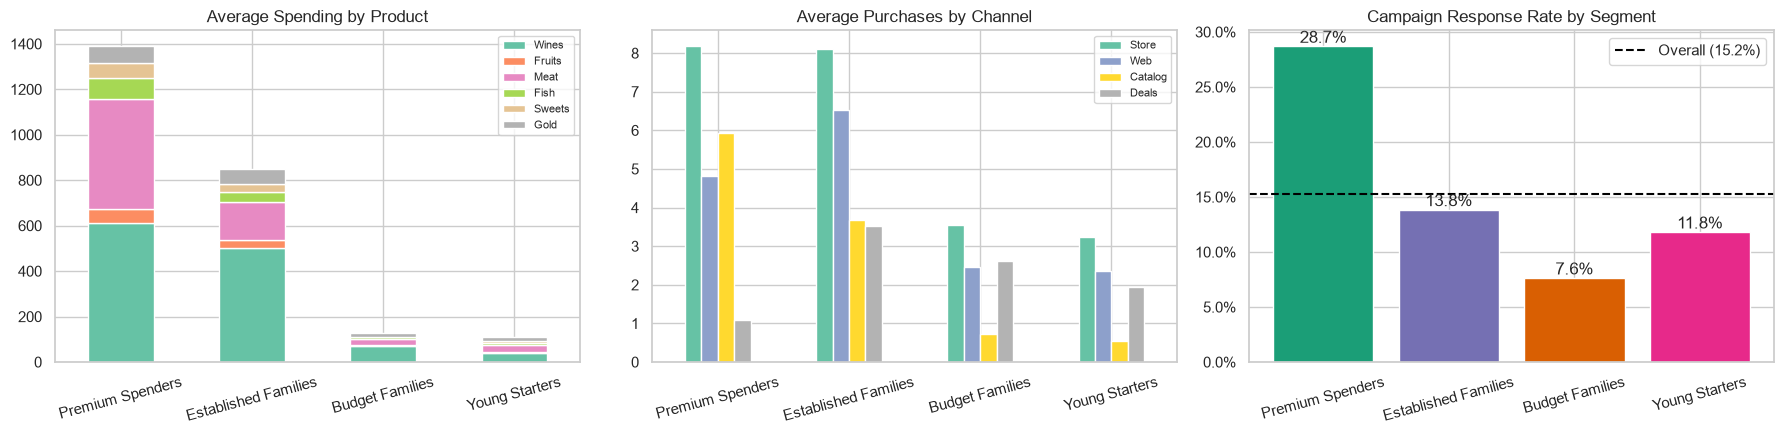

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
prod_seg = df.groupby("Segment")[utils.MNT_COLS].mean().reindex(seg_order)
prod_seg.columns = ["Wines", "Fruits", "Meat", "Fish", "Sweets", "Gold"]
prod_seg.plot(kind="bar", stacked=True, ax=ax[0], colormap="Set2", rot=15)
ax[0].set_title("Average Spending by Product"); ax[0].set_xlabel(""); ax[0].legend(fontsize=8)

ch_seg = df.groupby("Segment")[["NumStorePurchases", "NumWebPurchases", "NumCatalogPurchases", "NumDealsPurchases"]].mean().reindex(seg_order)
ch_seg.columns = ["Store", "Web", "Catalog", "Deals"]
ch_seg.plot(kind="bar", ax=ax[1], colormap="Set2", rot=15)
ax[1].set_title("Average Purchases by Channel"); ax[1].set_xlabel(""); ax[1].legend(fontsize=8)

resp_seg = df.groupby("Segment")["Response"].mean().reindex(seg_order)
bars = ax[2].bar(resp_seg.index, resp_seg.values, color=[seg_colors[s] for s in seg_order])
ax[2].axhline(df["Response"].mean(), color="black", ls="--", label=f"Overall ({df['Response'].mean():.1%})")
for b, v in zip(bars, resp_seg.values):
    ax[2].text(b.get_x() + b.get_width() / 2, v, f"{v:.1%}", ha="center", va="bottom")
ax[2].set_title("Campaign Response Rate by Segment"); ax[2].tick_params(axis="x", rotation=15)
ax[2].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0)); ax[2].legend()
save("21_segment_spending_channels_response"); plt.show()

In [43]:
seg_value = pd.DataFrame({
    "Customers": df["Segment"].value_counts(),
    "% of customers": df["Segment"].value_counts(normalize=True) * 100,
    "% of total revenue": df.groupby("Segment")["Total_Spent"].sum() / df["Total_Spent"].sum() * 100,
    "Response rate %": df.groupby("Segment")["Response"].mean() * 100,
    "% of all responders": df.groupby("Segment")["Response"].sum() / df["Response"].sum() * 100,
}).reindex(seg_order)
seg_value.round(1)

,Customers,% of customers,% of total revenue,Response rate %,% of all responders
Segment,,,,,
Premium Spenders,453,22.1,50.5,28.7,41.5
Established Families,585,28.5,39.8,13.8,25.9
Budget Families,432,21.0,4.4,7.6,10.5
Young Starters,584,28.4,5.3,11.8,22.0


### 5.6 Segment Descriptions and Marketing Strategy

In [44]:
strategy_table = seg_profile[["Customers", "Income", "Total_Spent", "Age", "Children", "Response"]].copy()
strategy_table["Response"] = (strategy_table["Response"] * 100).round(1).astype(str) + "%"
strategy_table["Recommended strategy"] = [utils.STRATEGY[s] for s in seg_order]
pd.set_option("display.max_colwidth", 120)
strategy_table.round({"Income": 0, "Total_Spent": 0, "Age": 0, "Children": 1})

,Customers,Income,Total_Spent,Age,Children,Response,Recommended strategy
Segment,,,,,,,
Premium Spenders,453,78354.0,1389.0,45.0,0.1,28.7%,"Luxury wine & meat offers, VIP / loyalty program, catalog campaigns. Top priority for every campaign."
Established Families,585,60589.0,847.0,50.0,1.1,13.8%,"Value bundles and deals (they use discounts often), store and catalog promotions, upgrade offers to move them to pre..."
Budget Families,432,41975.0,128.0,50.0,1.9,7.6%,"Discount coupons, family and kids' product bundles, in-store promotions. Keep contact cost low."
Young Starters,584,30496.0,112.0,37.0,0.8,11.8%,"Web and mobile promotions, first-purchase coupons, retargeting ads (they visit the website often but buy little)."


**Segment insights**

| Segment | Who they are | Key numbers | Marketing action |
|---|---|---|---|
| **Premium Spenders** (22%) | Highest income (≈78k), almost no children, buy through catalog and store, rarely use discounts or visit the website | Spend ≈1,389; generate **50% of revenue**; response **28.7%** (≈2× average) | VIP / loyalty program, premium wine & meat offers via catalog. **Contact in every campaign.** |
| **Established Families** (28%) | Upper-middle income (≈61k), older (≈50), mostly teenagers at home, loyal (longest tenure), **heavy deal users** | Spend ≈847; **40% of revenue**; response 13.8% | Value bundles and discount deals, store/catalog promotions; upgrade offers to move them towards premium |
| **Budget Families** (21%) | Lower income (≈42k), ≈2 children (kids + teens), few purchases, many website visits | Spend ≈128; only 4% of revenue; **lowest response (7.6%)** | Low-cost channels only: coupons, family bundles, in-store promotions. Avoid expensive campaigns |
| **Young Starters** (28%) | Youngest (≈37), lowest income (≈30k), small households, **visit the website most but buy little** | Spend ≈112; 5% of revenue; response 11.8% | Web/mobile promotions, first-purchase coupons and retargeting to convert browsing into buying |

**Key business finding:** Premium Spenders and Established Families are **50% of customers but generate ≈90% of revenue and ≈67% of all campaign responders**. Concentrating campaign budget on these two segments (and using cheap digital channels for the other two) would greatly reduce wasted marketing spend.

### 5.7 Saving the Segmentation Model

In [45]:
joblib.dump(km_scaler, "models/kmeans_scaler.pkl")
joblib.dump(kmeans, "models/kmeans.pkl")
joblib.dump(pca, "models/pca.pkl")
joblib.dump(cluster_names, "models/cluster_names.pkl")
df.to_csv("data/customers_segmented.csv", index=False)
print("Saved: models/kmeans_scaler.pkl, models/kmeans.pkl, models/pca.pkl, models/cluster_names.pkl")
print("Saved: data/customers_segmented.csv", df.shape)

Saved: models/kmeans_scaler.pkl, models/kmeans.pkl, models/pca.pkl, models/cluster_names.pkl
Saved: data/customers_segmented.csv (2054, 40)


## Step 6: Classification – Predicting Campaign Response
**Business question:** *Which customers are likely to accept the next marketing offer?*
If we can predict this, the company can contact only likely responders and stop wasting money on the rest.

- **Target:** `Response` (1 = accepted the last campaign, 0 = did not) – **15.2% positives (imbalanced)**
- **Features:** demographics, income, spending by product, purchase channels, recency, tenure, previous campaign acceptances and the **segment from Step 5** (one-hot encoded)
- **Models:** Logistic Regression, Decision Tree, Random Forest

**Approach**
1. **Stratified 80/20 train-test split** (Step 3 showed stratification keeps the 15% response rate in both sets)
2. Handle class imbalance with `class_weight="balanced"` (mistakes on the rare "Yes" class cost more)
3. Tune each model with **GridSearchCV + 5-fold stratified cross-validation** on the training set only
4. Compare on the untouched test set using Accuracy, Precision, Recall, F1 and **ROC-AUC**

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             precision_recall_curve)
import json

seg_dummies = pd.get_dummies(df["Segment"], prefix="Seg", dtype=int)
X = pd.concat([df[utils.CLF_FEATURES], seg_dummies], axis=1)
y = df["Response"]
FEATURES = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Features:", len(FEATURES))
print(f"Train: {X_train.shape[0]} customers ({y_train.mean():.1%} responders)")
print(f"Test : {X_test.shape[0]} customers ({y_test.mean():.1%} responders)")

Features: 26
Train: 1643 customers (15.2% responders)
Test : 411 customers (15.3% responders)


### 6.1 Why accuracy alone is misleading
A "model" that predicts **No for everyone** would already be ≈85% accurate – but it would find **zero** responders. So we focus on:
- **Recall** – of all real responders, how many did we find? (missed responders = lost revenue)
- **Precision** – of the customers we target, how many actually respond? (wrong targets = wasted cost)
- **F1** – balance of precision and recall
- **ROC-AUC** – how well the model ranks responders above non-responders (0.5 = random, 1.0 = perfect)

In [47]:
baseline_pred = np.zeros_like(y_test)
print(f"Always-'No' baseline -> Accuracy: {accuracy_score(y_test, baseline_pred):.1%}, Recall: {recall_score(y_test, baseline_pred):.0%}")

Always-'No' baseline -> Accuracy: 84.7%, Recall: 0%


### 6.2 Training and Tuning the Three Models

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "Logistic Regression": (
        Pipeline([("scaler", StandardScaler()),
                  ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))]),
        {"model__C": [0.01, 0.1, 1, 10]}),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        {"max_depth": [3, 4, 5, 6, 8], "min_samples_leaf": [5, 10, 20]}),
    "Random Forest": (
        RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
        {"max_depth": [5, 8, 12, None], "min_samples_leaf": [1, 3, 5, 10]}),
}

models, cv_auc = {}, {}
for name, (est, grid) in candidates.items():
    gs = GridSearchCV(est, grid, scoring="roc_auc", cv=cv, n_jobs=-1).fit(X_train, y_train)
    models[name] = gs.best_estimator_
    cv_auc[name] = gs.best_score_
    print(f"{name:20s} best params: {gs.best_params_}  |  CV ROC-AUC: {gs.best_score_:.3f}")

Logistic Regression  best params: {'model__C': 0.1}  |  CV ROC-AUC: 0.892


Decision Tree        best params: {'max_depth': 6, 'min_samples_leaf': 20}  |  CV ROC-AUC: 0.825


Random Forest        best params: {'max_depth': None, 'min_samples_leaf': 5}  |  CV ROC-AUC: 0.885


### 6.3 Model Comparison on the Test Set

In [49]:
results, probas = [], {}
for name, m in models.items():
    p = m.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    probas[name] = p
    results.append({"Model": name, "CV ROC-AUC": cv_auc[name],
                    "Test Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                    "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
                    "Test ROC-AUC": roc_auc_score(y_test, p)})
results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,CV ROC-AUC,Test Accuracy,Precision,Recall,F1,Test ROC-AUC
Model,,,,,,
Logistic Regression,0.892,0.791,0.408,0.810,0.543,0.885
Decision Tree,0.825,0.723,0.329,0.778,0.462,0.788
Random Forest,0.885,0.837,0.478,0.683,0.562,0.875


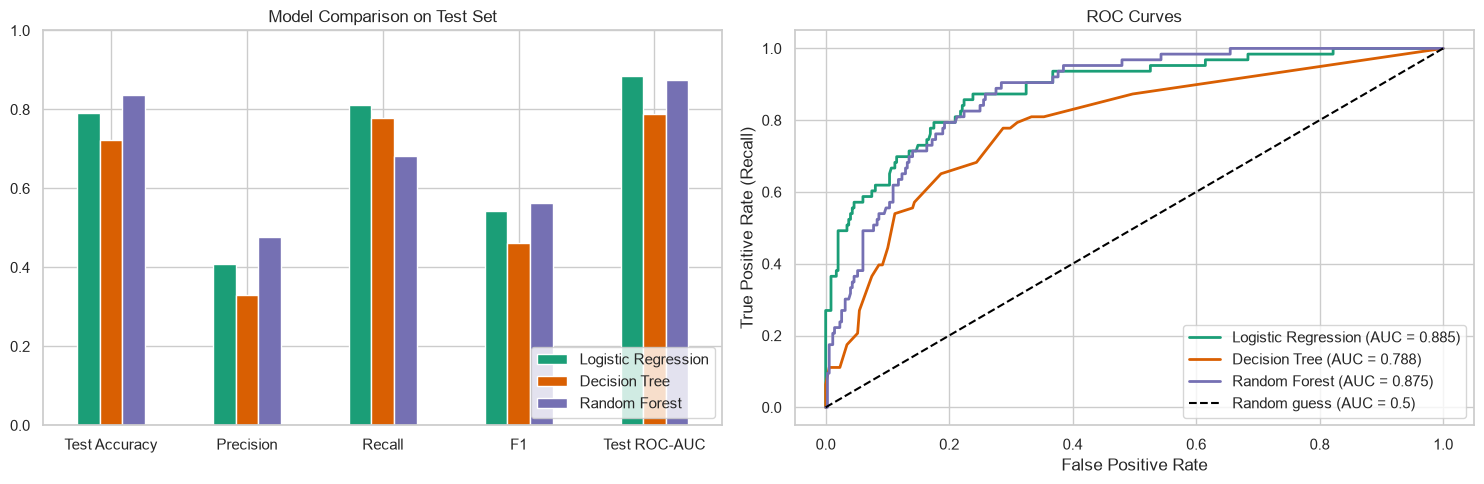

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
results_df[["Test Accuracy", "Precision", "Recall", "F1", "Test ROC-AUC"]].T.plot(kind="bar", ax=ax[0], rot=0,
                                                                                  color=["#1b9e77", "#d95f02", "#7570b3"])
ax[0].set_title("Model Comparison on Test Set"); ax[0].set_ylim(0, 1); ax[0].legend(loc="lower right")
for name, col in zip(models, ["#1b9e77", "#d95f02", "#7570b3"]):
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    ax[1].plot(fpr, tpr, lw=2, color=col, label=f"{name} (AUC = {roc_auc_score(y_test, probas[name]):.3f})")
ax[1].plot([0, 1], [0, 1], "k--", label="Random guess (AUC = 0.5)")
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate (Recall)")
ax[1].set_title("ROC Curves"); ax[1].legend(loc="lower right")
save("22_model_comparison_roc"); plt.show()

In [51]:
best_name = max(cv_auc, key=cv_auc.get)
best_model = models[best_name]
print(f"Best model (chosen by cross-validated ROC-AUC on training data): {best_name}")

Best model (chosen by cross-validated ROC-AUC on training data): Logistic Regression


**Model comparison insights**
- All three models are far better than random guessing (AUC 0.5) and than the "always No" baseline (recall 0%).
- **Logistic Regression is the best model** – highest cross-validated AUC (0.892) and test AUC (0.885), and the **highest recall (81%)**: it finds 51 of the 63 real responders in the test set.
- **Random Forest** is very close (AUC 0.875) with the highest accuracy (83.7%) and precision (47.8%) but lower recall (68%) – it is more conservative.
- **Decision Tree** is the weakest (AUC 0.788) but the easiest to explain.
- A simple linear model wins because the main relationships (previous acceptances, recency, tenure) are **close to linear and additive**, and with ~2,000 customers the more complex Random Forest has little extra pattern to learn.
- The best model was chosen using **cross-validation on the training data**, so the test set stays an unbiased final check.

### 6.4 Confusion Matrices

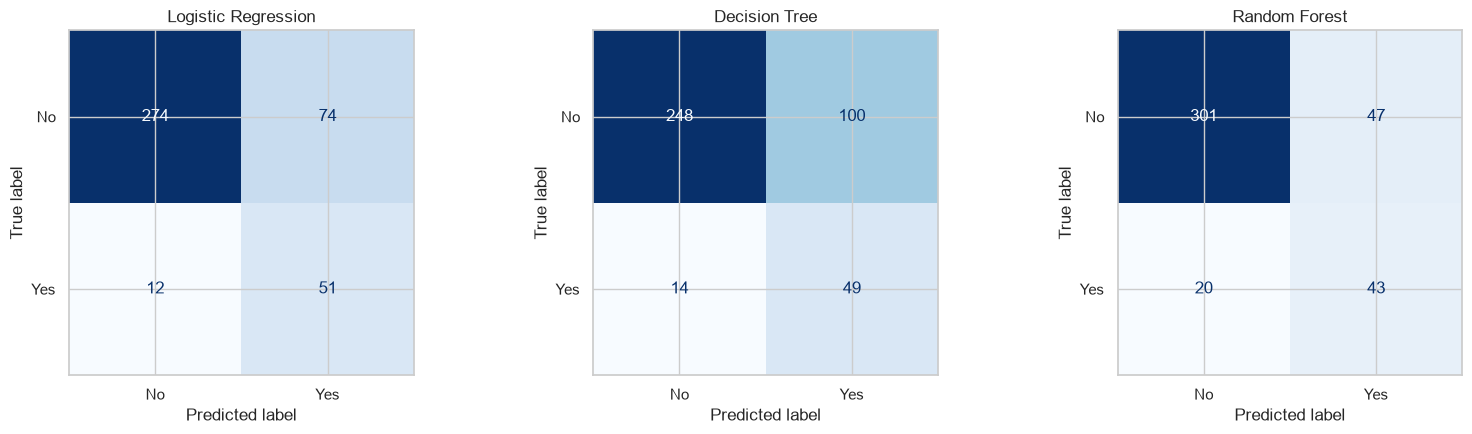

Classification report – Logistic Regression

              precision    recall  f1-score   support

 No response       0.96      0.79      0.86       348
    Response       0.41      0.81      0.54        63

    accuracy                           0.79       411
   macro avg       0.68      0.80      0.70       411
weighted avg       0.87      0.79      0.82       411



In [52]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, name in zip(ax, models):
    cm = confusion_matrix(y_test, (probas[name] >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(name)
save("23_confusion_matrices"); plt.show()
print(f"Classification report – {best_name}\n")
print(classification_report(y_test, (probas[best_name] >= 0.5).astype(int), target_names=["No response", "Response"]))

**Reading the confusion matrix (Logistic Regression, 411 test customers):**
- **True positives:** 51 responders correctly found (recall 81%).
- **False negatives:** only 12 responders missed.
- **False positives:** ≈ 74 customers predicted "Yes" who did not respond – the cost of contacting a few extra people.
- **True negatives:** ≈ 274 non-responders correctly skipped (no money wasted on them).

For marketing, a missed responder (lost sale) usually costs more than one extra contact (a mail or SMS), so **high recall with moderate precision is the right trade-off**. The probability threshold (0.5) can be raised if the company wants fewer, more certain targets.

### 6.5 What Drives Response? (Feature Importance)

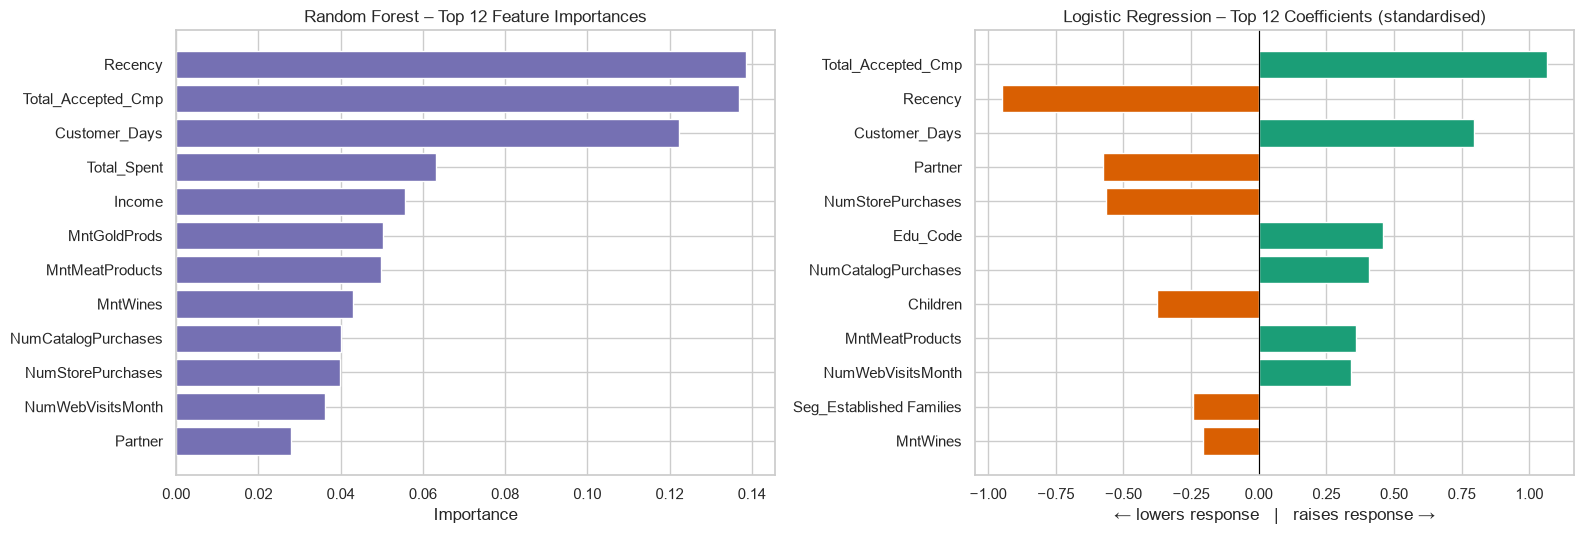

In [53]:
rf_imp = pd.Series(models["Random Forest"].feature_importances_, index=FEATURES).sort_values(ascending=False).head(12)
lr_coef = pd.Series(models["Logistic Regression"].named_steps["model"].coef_[0], index=FEATURES)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index).head(12)[::-1]

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
ax[0].barh(rf_imp.index[::-1], rf_imp.values[::-1], color="#7570b3")
ax[0].set_title("Random Forest – Top 12 Feature Importances"); ax[0].set_xlabel("Importance")
ax[1].barh(lr_top.index, lr_top.values, color=["#1b9e77" if v > 0 else "#d95f02" for v in lr_top.values])
ax[1].axvline(0, color="black", lw=0.8)
ax[1].set_title("Logistic Regression – Top 12 Coefficients (standardised)"); ax[1].set_xlabel("← lowers response   |   raises response →")
save("24_feature_importance"); plt.show()

In [54]:
odds = pd.DataFrame({"Coefficient": lr_coef, "Odds ratio (per 1 std dev)": np.exp(lr_coef)})
odds.reindex(lr_coef.abs().sort_values(ascending=False).index).head(10).round(3)

,Coefficient,Odds ratio (per 1 std dev)
Total_Accepted_Cmp,1.065,2.900
Recency,-0.947,0.388
Customer_Days,0.796,2.217
Partner,-0.577,0.562
NumStorePurchases,-0.563,0.569
Edu_Code,0.460,1.584
NumCatalogPurchases,0.407,1.503
Children,-0.377,0.686
MntMeatProducts,0.359,1.432
NumWebVisitsMonth,0.341,1.407


**Key drivers of campaign response** (both models agree on the top three):
1. **Total_Accepted_Cmp (+)** – each 1-std increase in previous acceptances multiplies the odds of responding by **≈ 2.9**. Past responders respond again.
2. **Recency (−)** – customers who bought recently are much more likely to respond (odds × 0.39 per 1-std more days since last purchase).
3. **Customer_Days (+)** – longer-standing (loyal) customers respond more (odds × 2.2).
4. **Partner (−) and Children (−)** – singles and customers without children respond more (matches EDA and chi-square tests).
5. **Catalog purchases, meat spending and education (+)** raise response; **store purchases (−)** lower it once the other factors are accounted for.

*Note:* Logistic regression coefficients show the effect of each feature **while holding the others constant**, which is why some differ from the simple one-variable comparisons in Step 3.

### 6.6 Decision Tree Rules (interpretable model)

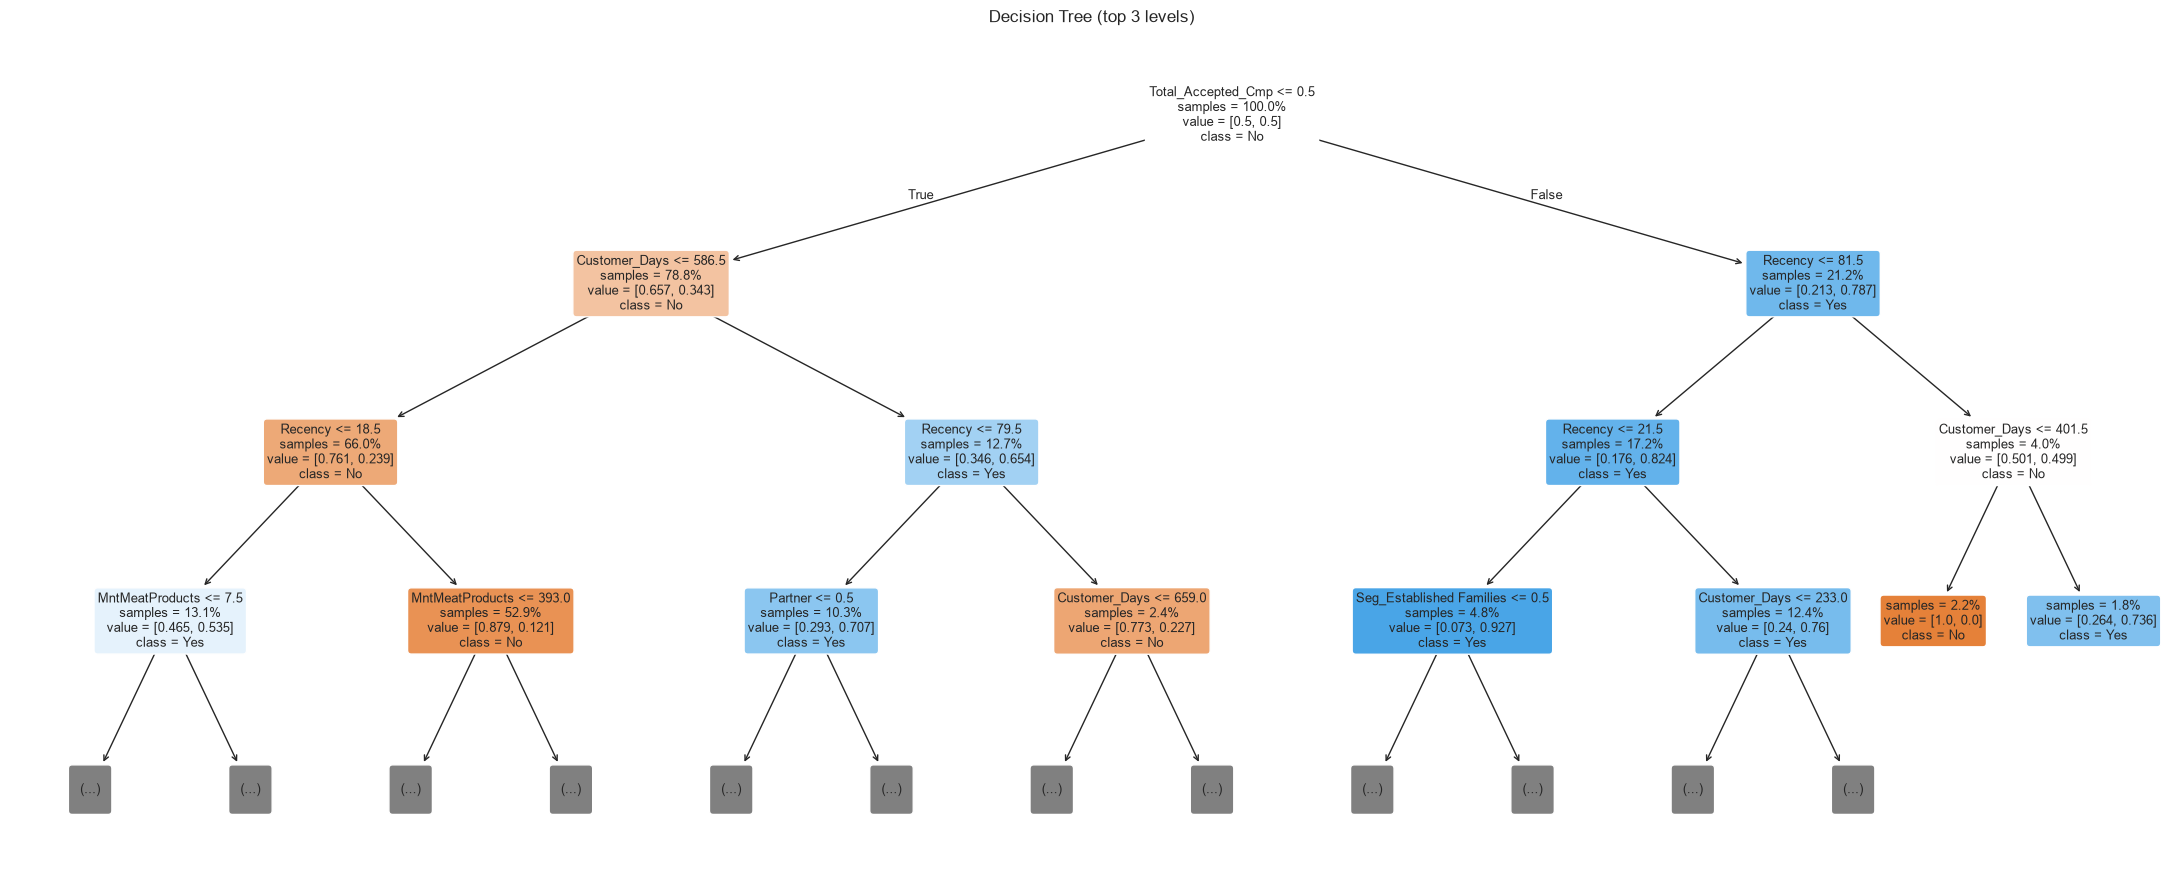

In [55]:
plt.figure(figsize=(22, 9))
plot_tree(models["Decision Tree"], feature_names=FEATURES, class_names=["No", "Yes"], filled=True,
          max_depth=3, fontsize=9, rounded=True, proportion=True, impurity=False)
plt.title("Decision Tree (top 3 levels)")
save("25_decision_tree"); plt.show()

The tree shows simple **if-then rules** a marketing manager can understand, e.g. *"if the customer accepted earlier campaigns and bought recently → likely to respond"*. It is the easiest model to explain, but the least accurate.

### 6.7 Business Impact – Targeting Simulation
Instead of contacting everyone, the company contacts only the customers with the **highest predicted probability**. The **cumulative gains curve** shows what share of all responders is captured when contacting the top X% of customers (test set).

In [56]:
def gains_table(y_true, proba, steps=(10, 20, 30, 40, 50, 60, 80, 100)):
    order = np.argsort(-proba)
    y_sorted = np.asarray(y_true)[order]
    total = y_sorted.sum()
    rows = []
    for pct in steps:
        n = int(round(len(y_sorted) * pct / 100))
        found = y_sorted[:n].sum()
        rows.append({"Contact top %": pct, "Customers contacted": n, "Responders found": int(found),
                     "% of all responders captured": found / total * 100,
                     "Response rate of contacted group %": found / n * 100,
                     "Lift": (found / n) / y_sorted.mean()})
    return pd.DataFrame(rows).set_index("Contact top %")

gains = gains_table(y_test, probas[best_name])
gains.round(1)

,Customers contacted,Responders found,% of all responders captured,Response rate of contacted group %,Lift
Contact top %,,,,,
10,41,31,49.2,75.6,4.9
20,82,43,68.3,52.4,3.4
30,123,50,79.4,40.7,2.7
40,164,55,87.3,33.5,2.2
50,206,59,93.7,28.6,1.9
60,247,60,95.2,24.3,1.6
80,329,62,98.4,18.8,1.2
100,411,63,100.0,15.3,1.0


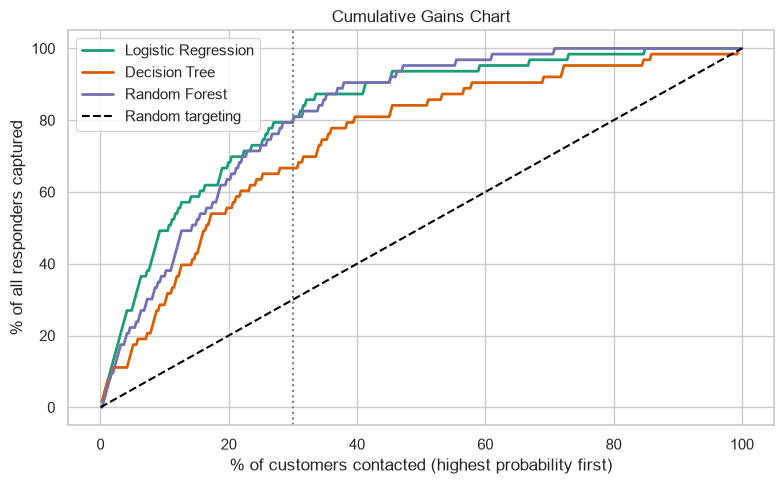

In [57]:
plt.figure(figsize=(8, 5))
for name, col in zip(models, ["#1b9e77", "#d95f02", "#7570b3"]):
    order = np.argsort(-probas[name])
    cum = np.cumsum(np.asarray(y_test)[order]) / y_test.sum()
    plt.plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum * 100, lw=2, color=col, label=name)
plt.plot([0, 100], [0, 100], "k--", label="Random targeting")
plt.axvline(30, color="grey", ls=":"); plt.xlabel("% of customers contacted (highest probability first)")
plt.ylabel("% of all responders captured"); plt.title("Cumulative Gains Chart"); plt.legend()
save("26_cumulative_gains"); plt.show()

**Business impact (test set):**
- Contacting only the **top 10%** of customers captures **49% of all responders** with a **75.6% response rate** (≈ 5× better than random).
- Contacting the **top 30%** captures **≈ 79% of responders** at a **40.7% response rate** (lift 2.7×) – while **cutting campaign contacts by 70%**.
- Contacting the **top 50%** captures **≈ 94% of responders** with half the cost.

In other words, the company can keep most of the campaign's sales while spending a fraction of the budget. The dashboard (Step 7) lets the marketing team choose the % to contact and download the target list.

### 6.8 Saving the Models and Scoring All Customers
For the dashboard, each customer gets a **response probability**. To keep it honest, every customer is scored by a model that **did not see that customer during training** (5-fold out-of-fold predictions).

In [58]:
for name, m in models.items():
    joblib.dump(m, f"models/{name.lower().replace(' ', '_')}.pkl")
joblib.dump(best_model, "models/response_model.pkl")
joblib.dump(FEATURES, "models/clf_features.pkl")

df["Response_Prob"] = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba")[:, 1]
df.to_csv("data/customers_scored.csv", index=False)

metrics = {"best_model": best_name,
           "classification": results_df.reset_index().to_dict(orient="records"),
           "gains": gains.reset_index().to_dict(orient="records"),
           "linear_regression": {"test_r2": float(r2_score(y_te, mlr_pred)),
                                 "rmse": float(mean_squared_error(y_te, mlr_pred) ** 0.5),
                                 "mae": float(mean_absolute_error(y_te, mlr_pred))},
           "cluster_names": {int(k): v for k, v in cluster_names.items()}}
with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved models: logistic_regression.pkl, decision_tree.pkl, random_forest.pkl, response_model.pkl, clf_features.pkl")
print("Saved: models/metrics.json, data/customers_scored.csv", df.shape)
print("Out-of-fold ROC-AUC on all customers:", round(roc_auc_score(y, df["Response_Prob"]), 3))

Saved models: logistic_regression.pkl, decision_tree.pkl, random_forest.pkl, response_model.pkl, clf_features.pkl
Saved: models/metrics.json, data/customers_scored.csv (2054, 41)
Out-of-fold ROC-AUC on all customers: 0.892
